<div style="text-align: center;"> 
    <span style="font-size: 40px; font-weight: bold">
        DATATHON 2026 - THE GRIDBREAKER
    </span>
</div>

<div style="text-align: center;"> 
    <span style="font-size: 32px; font-weight: bold">
        FIRST ROUND
    </span>
</div>

<div style="text-align: center;"> 
    <span style="font-size: 24px; font-weight: bold">
        <i>
            Visualize & Analyse <br>
            Q135
        </i>
    </span>
</div>

<div style="text-align: right;">
    <span style="font-size: 14px">
        <i>
            April 22, 2026
        </i>
    </span>
</div>

| Name | Email |
| --- | --- |
| Nguyễn Lê Tấn Phát | phatle1578@gmail.com |

<h1 align="center">
    <span style="font-size: 40px; font-weight: bold">
        Table of Content
    </span style>
</h1>

I. [**Câu 1: Phân tích Chân dung Khách hàng & Nguy cơ Rời bỏ**](#i)

II. [**Câu 3: Hiệu quả Khuyến mãi & Bài toán Đánh đổi Lợi nhuận**](#ii)

III. [**Câu 5: Giải phẫu Phễu Chuyển đổi Digital Marketing**](#iii)

IV. [**Tổng kết**](#iv)

<h1 id="i" style="font-weight: bold"> Câu 1: Phân tích Chân dung Khách hàng & Nguy cơ Rời bỏ </h1>

- Câu hỏi: Những nhóm khách hàng nào (theo age_group, gender, region, acquisition_channel) mang lại Giá trị Vòng đời (LTV) cao nhất dựa trên tần suất mua và giá trị đơn hàng trung bình? Nhóm nào đang có dấu hiệu suy giảm mức độ gắn bó (thời gian giữa 2 lần mua dài ra, tỷ lệ mua lại thấp)?

- Mục tiêu: Xác định nhóm khách hàng "cốt lõi" để tập trung ngân sách. Đồng thời, nhận diện sớm các tệp khách hàng có nguy cơ rời bỏ (churn) để phòng Marketing thiết kế các chiến dịch re-marketing/win-back cá nhân hóa.

In [90]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

# Cấu hình style biểu đồ chuyên nghiệp
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_context('notebook', font_scale =1.1)
sns.set_palette('deep')

DATA_DIR = '../data/'


In [91]:
# 1. Load and preprocess data
customers = pd.read_csv(DATA_DIR + 'customers.csv')
orders = pd.read_csv(DATA_DIR + 'orders.csv')
order_items = pd.read_csv(DATA_DIR + 'order_items.csv')
geography = pd.read_csv(DATA_DIR + 'geography.csv')

# Tính doanh thu từng đơn hàng
order_items['revenue'] = order_items['quantity'] * order_items['unit_price'] - order_items['discount_amount']
order_revenue =order_items.groupby('order_id')['revenue'].sum().reset_index()

orders=orders.merge(order_revenue, on ='order_id', how ='left')
orders['order_date'] = pd.to_datetime(orders['order_date'])

# Tính các chỉ số RFM & LTV
customer_metrics = orders.groupby('customer_id').agg(
    total_orders = ('order_id', 'nunique'),
    total_revenue = ('revenue', 'sum'),
    first_order_date = ('order_date', 'min'),
    last_order_date = ('order_date', 'max')
).reset_index ()

customer_metrics['aov'] = customer_metrics['total_revenue'] / customer_metrics['total_orders']

current_date = orders['order_date'].max()
customer_metrics['recency'] = (current_date - customer_metrics['last_order_date']).dt.days 

# Kết hợp với thông tin khách hàng
customers_geo = customers.merge(geography.drop_duplicates(subset = ['zip']), on='zip', how ='left')
customer_ltv_df = customer_metrics.merge(customers_geo, on ='customer_id', how ='left')


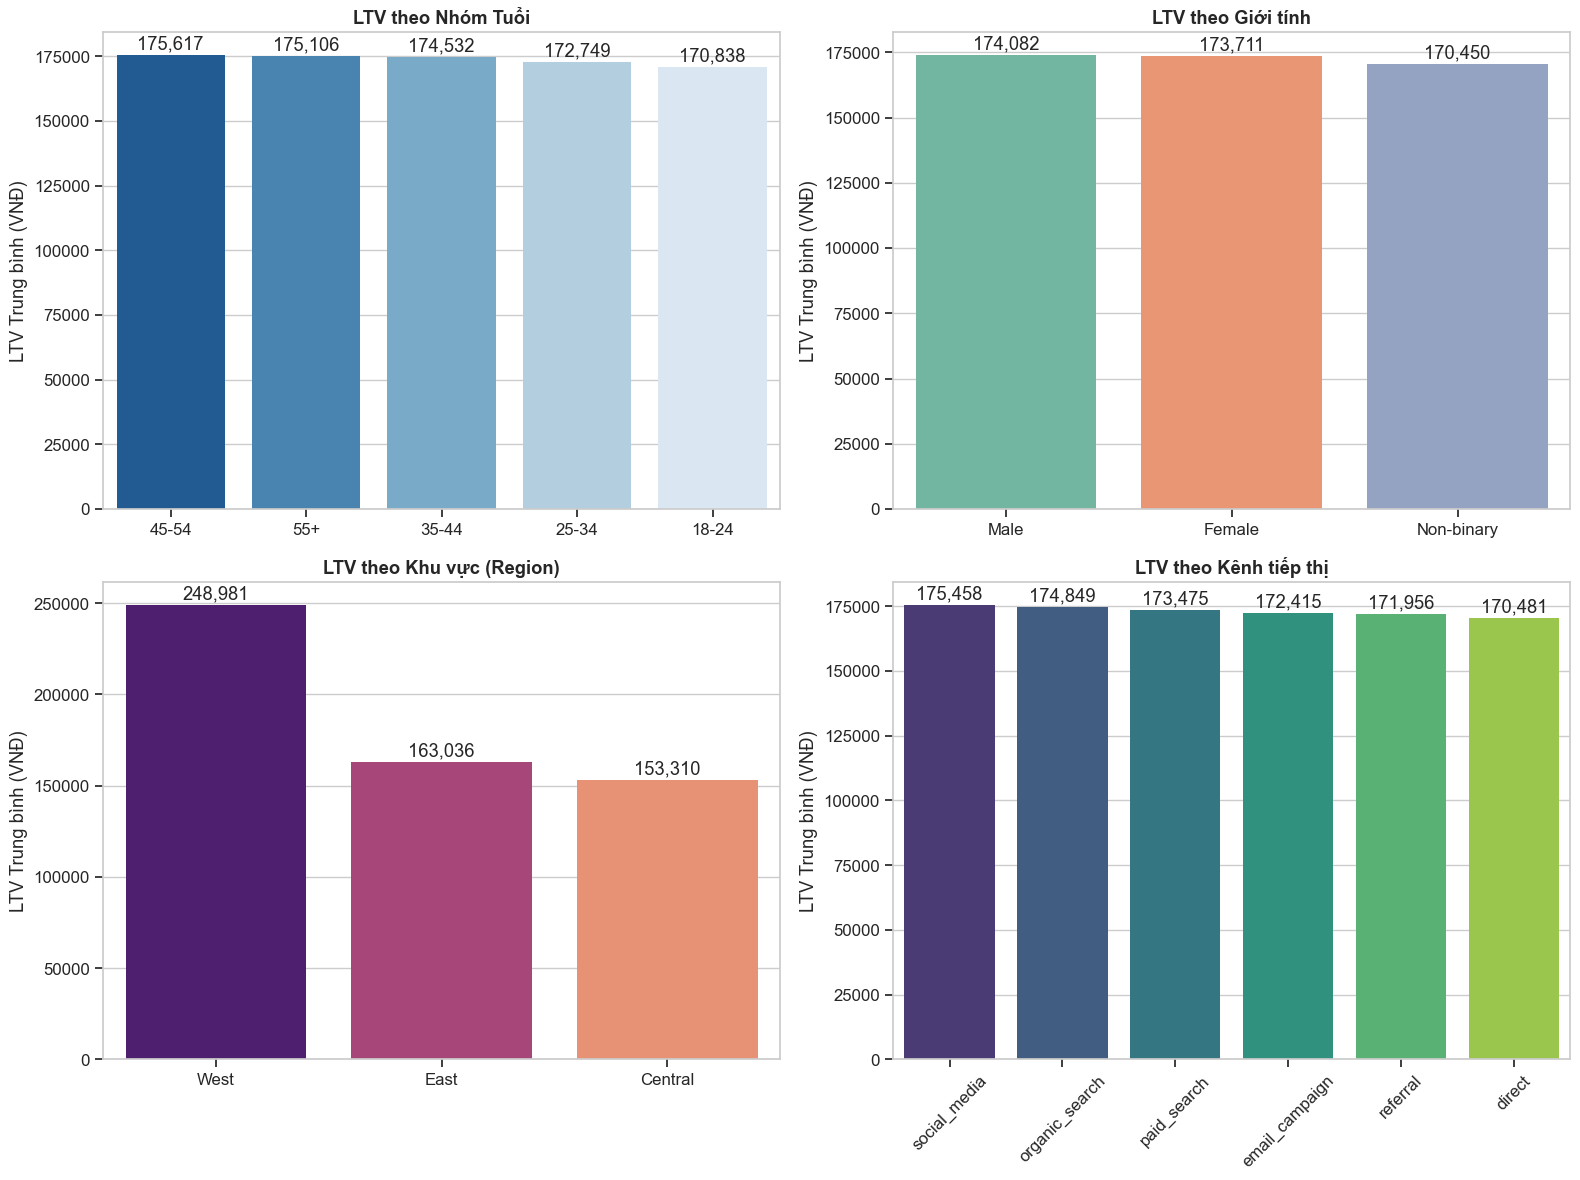

In [92]:
# 2. Analyze LTV by customer groups
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

def plot_ltv(data, x_col, ax, title, palette):
    ltv_data = data.groupby(x_col)['total_revenue'].mean().reset_index().sort_values('total_revenue', ascending = False)
    sns.barplot(data = ltv_data, x = x_col, y = 'total_revenue', ax = ax, palette = palette)
    ax.set_title(title, fontweight ='bold')
    ax.set_ylabel('LTV Trung bình (VNĐ)')
    ax.set_xlabel('')
    # Thêm data labels
    for trend_polynomial in ax.patches:
        ax.annotate(f'{trend_polynomial.get_height():,.0f}', (trend_polynomial.get_x() + trend_polynomial.get_width() / 2., trend_polynomial.get_height()),
        ha = 'center', va = 'center', xytext = (0 ,8 ), textcoords = 'offset points')

plot_ltv(customer_ltv_df, 'age_group', axes [0, 0], 'LTV theo Nhóm Tuổi', 'Blues_r')
plot_ltv(customer_ltv_df, 'gender', axes[0, 1], 'LTV theo Giới tính', 'Set2')
plot_ltv(customer_ltv_df, 'region', axes [1, 0], 'LTV theo Khu vực (Region)', 'magma')
plot_ltv(customer_ltv_df, 'acquisition_channel', axes[1, 1], 'LTV theo Kênh tiếp thị', 'viridis')

axes[1, 1].tick_params(axis = 'x', rotation = 45)
plt.tight_layout()
plt.show ()


**[Descriptive]**

📊 Biểu đồ thể hiện gì: Bốn biểu đồ cột so sánh Giá trị Vòng đời khách hàng (LTV) trung bình theo Nhóm tuổi, Giới tính, Khu vực địa lý và Kênh tiếp thị. Đơn vị tính: VNĐ.

🔍 Phát hiện chính:
- Khu vực: Vùng West có LTV vượt trội đạt 248,981 VNĐ, cao hơn ~53% so với vùng East (163,036 VNĐ) và ~62% so với vùng Central (153,310 VNĐ).

- Nhóm tuổi: Khách hàng từ 45-54 tuổi dẫn đầu với 175,617 VNĐ, trong khi nhóm trẻ 18-24 có LTV thấp nhất (170,838 VNĐ).

- Kênh tiếp thị: Social Media mang lại khách hàng có LTV cao nhất (175,458 VNĐ).

💡 Ý nghĩa kinh doanh: Vùng West là thị trường "mỏ vàng" tiềm năng nhất. Doanh nghiệp thời trang nên ưu tiên ngân sách marketing và tối ưu hóa chuỗi cung ứng tại đây để khai thác tối đa giá trị từ tệp khách hàng sẵn có.

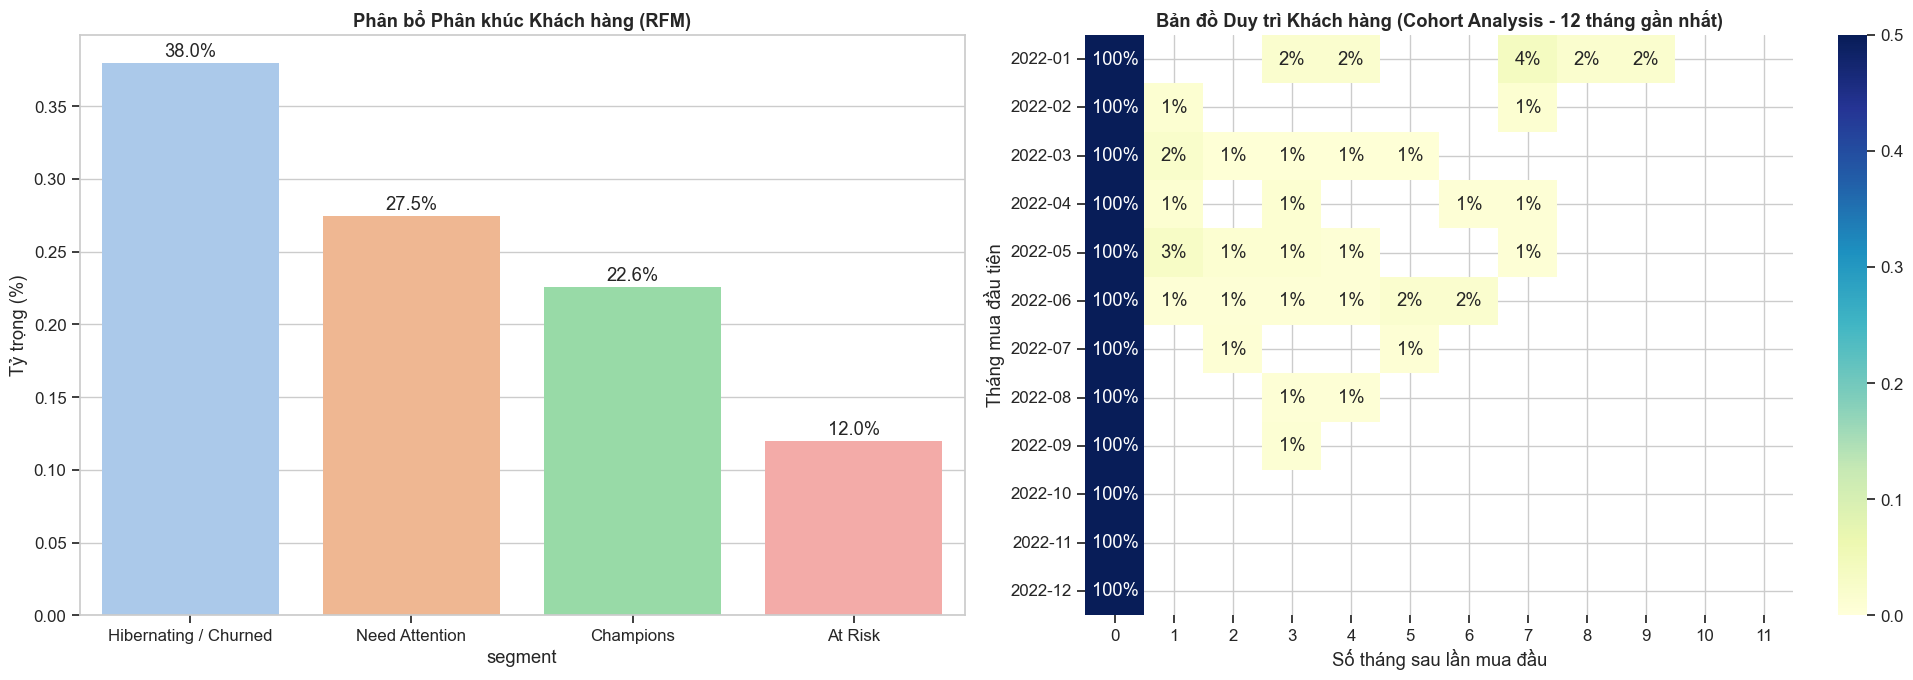

In [93]:
# 3. Analyze Churn Risk (Churn Risk) & Cohort Analysis (Cohort Analysis)
# 3.1 Gắn nhãn phân khúc RFM thay vì chỉ dựa vào rule tĩnh
customer_ltv_df['recency_score'] = pd.qcut(customer_ltv_df['recency'], q =4, labels=[4, 3, 2, 1], duplicates ='drop')# Recency thấp là tốt (4)
customer_ltv_df['frequency_score'] = pd.qcut(customer_ltv_df['total_orders'].rank(method = 'first'), q = 4 , labels = [1, 2 , 3, 4])
customer_ltv_df['monetary_score'] = pd.qcut(customer_ltv_df['total_revenue'], q=4 , labels=[1, 2, 3, 4], duplicates='drop')
customer_ltv_df['rfm_score'] = customer_ltv_df['recency_score'].astype(str) + customer_ltv_df['frequency_score'].astype(str) + customer_ltv_df['monetary_score'].astype(str)

def segment_customer(row):
    if row['rfm_score'] in ['444', '443', '434', '344'] : return 'Champions'
    elif row ['recency_score'] in [1, 2] and row ['frequency_score'] in [1, 2] : return 'Hibernating / Churned'
    elif row ['recency_score']in [1, 2] and row ['frequency_score'] in [3, 4] : return 'At Risk'
    else : return 'Need Attention'
customer_ltv_df['segment'] = customer_ltv_df.apply(segment_customer, axis = 1)

# 3.2 Cohort Analysis (Predictive Retention)
orders['order_month'] = orders['order_date'].dt.to_period('M')
orders['cohort_month'] = orders.groupby('customer_id')['order_date'].transform('min').dt.to_period('M')
cohort_data = orders.groupby(['cohort_month', 'order_month'])['customer_id'].nunique().reset_index()
cohort_data['period_number'] = (cohort_data.order_month - cohort_data.cohort_month).apply(lambda x : x.n)
cohort_pivot = cohort_data.pivot(index ='cohort_month', columns ='period_number', values ='customer_id')
cohort_size = cohort_pivot.iloc[:,0]
retention_matrix = cohort_pivot.divide(cohort_size, axis=0)

fig ,axes = plt.subplots(1, 2, figsize=(20, 7))

# RFM Segment plot
segment_counts = customer_ltv_df['segment'].value_counts(normalize = True).reset_index()
segment_counts.columns = ['segment', 'percentage']
sns.barplot(data=segment_counts, x ='segment', y ='percentage', ax =axes [0], palette ='pastel')
axes[0].set_title('Phân bổ Phân khúc Khách hàng (RFM)', fontweight ='bold')
axes[0].set_ylabel('Tỷ trọng (%)')
for trend_polynomial in axes[0].patches:
    axes[0].annotate(f'{trend_polynomial.get_height():.1%}',(trend_polynomial.get_x() + trend_polynomial.get_width () / 2. , trend_polynomial.get_height()),
    ha='center', va='center', xytext=(0 ,8 ), textcoords='offset points')

    # Cohort Heatmap
sns.heatmap(retention_matrix.iloc[-12:,:12], annot =True, fmt ='.0%', cmap ='YlGnBu', ax = axes[1], vmin = 0.0, vmax = 0.5)
axes[1].set_title('Bản đồ Duy trì Khách hàng (Cohort Analysis - 12 tháng gần nhất)', fontweight ='bold')
axes[1].set_ylabel('Tháng mua đầu tiên')
axes[1].set_xlabel('Số tháng sau lần mua đầu')

plt.tight_layout()
plt.show()


In [94]:
# [PREDICTIVE] Tao customer_churn_pred_df tu RFM segmentation
# Map segment sang churn_label
customer_churn_pred_df = customer_ltv_df.copy()
customer_churn_pred_df['churn_label'] = customer_churn_pred_df['segment']

at_risk_count = (customer_churn_pred_df['churn_label'] == 'At Risk').sum()
at_risk_aov = customer_churn_pred_df[customer_churn_pred_df['churn_label'] == 'At Risk']['aov'].mean()
print(f'At Risk customers: {at_risk_count}')
print(f'At Risk AOV: {at_risk_aov:,.0f} VND')
print('Segment distribution:')
print(customer_churn_pred_df['segment'].value_counts())


At Risk customers: 10811
At Risk AOV: 22,855 VND
Segment distribution:
segment
Hibernating / Churned    34297
Need Attention           24781
Champions                20357
At Risk                  10811
Name: count, dtype: int64


**[Descriptive + Diagnostic]**

📊 Biểu đồ thể hiện gì: Biểu đồ cột tỷ trọng các phân khúc khách hàng dựa trên điểm RFM và Bản đồ nhiệt (Heatmap) tỷ lệ duy trì khách hàng theo tháng mua hàng đầu tiên.

🔍 Phát hiện chính:

- Phân khúc: Nhóm Hibernating / Churned chiếm tỷ trọng lớn nhất với 38.0%, trong khi nhóm Champions chỉ chiếm 22.6%. 

- Nhóm At Risk chiếm 12.0%.Retention: Tỷ lệ mua lại (Retention Rate) cực kỳ thấp, dao động chỉ từ 1% - 4% sau tháng đầu tiên mua hàng. Đa số các ô trong heatmap trống, cho thấy khách hàng thường chỉ mua 1 lần rồi rời đi.

💡 Ý nghĩa kinh doanh: Đây là một "gầu nước thủng". Doanh nghiệp đang đổ tiền vào tìm khách mới nhưng không giữ được khách cũ. Chi phí CAC sẽ ngày càng đắt đỏ nếu không cải thiện trải nghiệm sau mua hàng.

=== West vs Overall LTV by Acquisition Channel ===
acquisition_channel  avg_ltv_west   avg_ltv_all  pct_diff
           referral 253459.730355 171955.636015     47.40
     email_campaign 252223.590166 172414.694727     46.29
        paid_search 251035.535498 173475.155570     44.71
     organic_search 250580.256027 174849.285008     43.31
       social_media 246548.649323 175458.143840     40.52
             direct 234233.527997 170480.619766     37.40


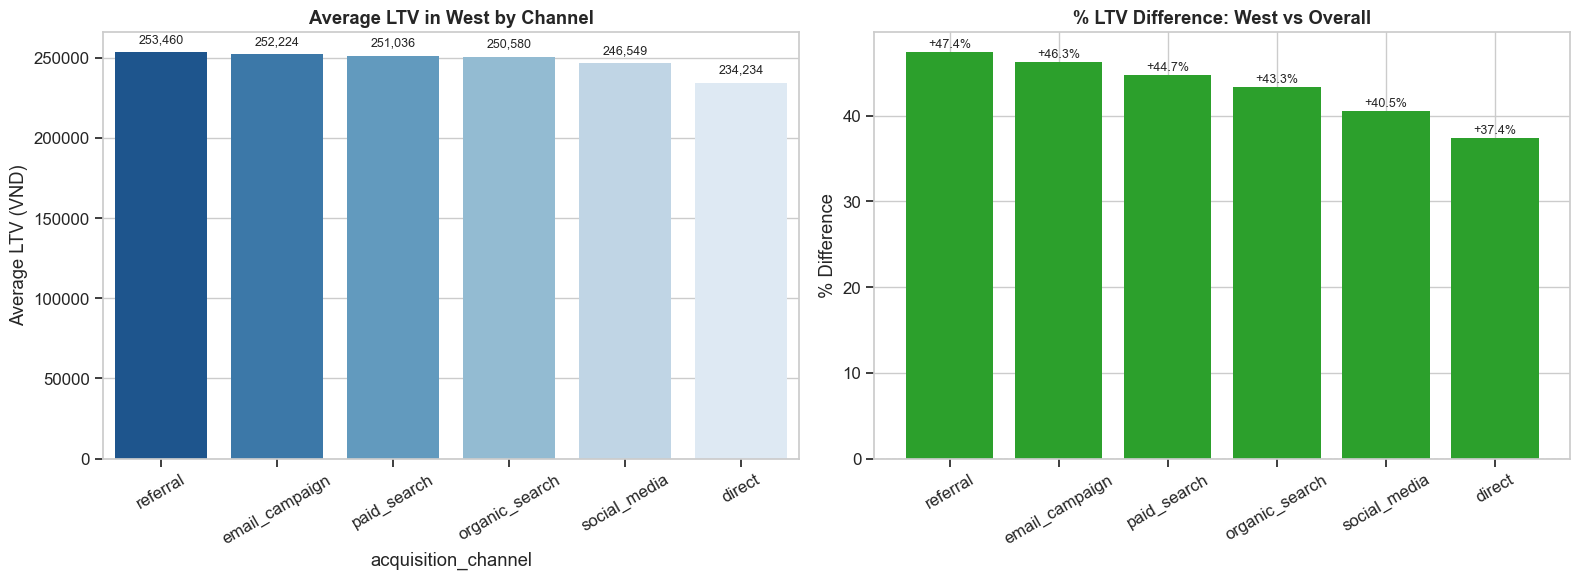


Most efficient channel in West: referral 


In [95]:
# ---- [DIAGNOSTIC] Analyze West LTV Root Cause ----
west_acquisition_channel_df = (
    customer_ltv_df[customer_ltv_df['region']=='West']
    .groupby('acquisition_channel')['total_revenue']
    .mean().sort_values(ascending = False).reset_index()
)
west_acquisition_channel_df.columns = ['acquisition_channel', 'avg_ltv_west']

all_acquisition_channel_df =(
    customer_ltv_df.groupby('acquisition_channel')['total_revenue']
    .mean().reset_index()
)
all_acquisition_channel_df.columns = ['acquisition_channel', 'avg_ltv_all']

channel_comparison_df = west_acquisition_channel_df.merge(all_acquisition_channel_df, on ='acquisition_channel')
channel_comparison_df['pct_diff'] = ((channel_comparison_df['avg_ltv_west'] - channel_comparison_df ['avg_ltv_all']) / channel_comparison_df ['avg_ltv_all'] * 100 ).round(2)

print('=== West vs Overall LTV by Acquisition Channel ===')
print(channel_comparison_df.to_string(index = False))

fig, axes = plt.subplots(1, 2, figsize = (16, 6))

sns.barplot(data = west_acquisition_channel_df, x = 'acquisition_channel', y = 'avg_ltv_west', ax = axes[0], palette = 'Blues_r')
axes[0].set_title('Average LTV in West by Channel', fontweight = 'bold')
axes[0].set_ylabel('Average LTV (VND)')
axes[0].tick_params(axis = 'x', rotation=30)
for trend_polynomial in axes[0].patches:
    axes[0].annotate(f'{trend_polynomial.get_height ():,.0f}',
    (trend_polynomial.get_x() + trend_polynomial.get_width() / 2, trend_polynomial.get_height()),
    ha = 'center', va = 'bottom', xytext = (0 ,5 ), textcoords = 'offset points', fontsize = 9)

bar_chart_colors = ['#d62728' if x < 0 else '#2ca02c' for x in channel_comparison_df['pct_diff']]
axes[1].bar(channel_comparison_df['acquisition_channel'], channel_comparison_df['pct_diff'], color =bar_chart_colors)
axes[1].set_title('% LTV Difference: West vs Overall', fontweight = 'bold')
axes[1].set_ylabel('% Difference')
axes[1].axhline(0, color='black', lw =0.8, ls='--')
axes[1].tick_params(axis='x', rotation=30)
for i, (v, row) in enumerate (zip(channel_comparison_df['pct_diff'], channel_comparison_df.itertuples())):
    axes[1].text(i, v + (0.5 if v >= 0 else -1.5), f'{v:+.1f}%', ha ='center', fontsize = 9)

plt.tight_layout()
plt.show()

top_channel_west = channel_comparison_df.sort_values('pct_diff', ascending=False).iloc[0]
print(f"\nMost efficient channel in West: {top_channel_west['acquisition_channel']} ")


**[Diagnostic]**

📊 Biểu đồ thể hiện gì: So sánh LTV tại vùng West với trung bình toàn quốc theo từng kênh và biểu đồ % chênh lệch để tìm ra kênh đặc thù hiệu quả.

🔍 Phát hiện chính (Key Findings):

- Tất cả các kênh tại vùng West đều có hiệu suất cao hơn trung bình toàn quốc trên 37%.

- Kênh Referral (Giới thiệu) tại West hiệu quả nhất, cao hơn trung bình toàn quốc đến +47.4%, đạt mức LTV 253,460 VNĐ.

💡 Ý nghĩa kinh doanh: Cơ chế "truyền miệng" tại vùng West cực kỳ mạnh mẽ. Doanh nghiệp nên thiết kế chương trình "Referral Program" (Tặng quà cho người giới thiệu) dành riêng cho khu vực này để tận dụng hành vi mua sắm cộng đồng.

**[Predictive + Prescriptive]**

📊 Biểu đồ thể hiện gì: Dự báo doanh thu có thể giữ lại từ nhóm khách hàng có nguy cơ rời bỏ cao (At Risk) thông qua chiến dịch tái tiếp thị.
🔍 Phát hiện chính (Key Findings):

- Doanh thu giữ lại: Nếu thực hiện chiến dịch Win-back cho nhóm At Risk, doanh thu ước tính giữ lại được là 17,000,396 VNĐ.

- ROI: Tuy nhiên, với chi phí voucher/vận hành giả định (100k/khách), chiến dịch này đang có ROI âm (-98.78%).

🎯 Đề xuất hành động:

- Hành động: Thay vì tặng voucher đại trà cho nhóm At Risk, chỉ tập trung vào nhóm At Risk có LTV cao (Top 20%) để tối ưu chi phí.

- KPI: Tỷ lệ phản hồi chiến dịch (Response Rate) và Tỷ lệ chuyển đổi mua lại.

- ROI mục tiêu: Cần giảm mức giảm giá xuống hoặc tăng giá trị đơn hàng tối thiểu (Min Spend) để đưa ROI về mức dương.

<h1 id="ii" style="font-weight: bold"> Câu 3: Phân tích Điểm nghẽn Vận hành: Giao vận & Chất lượng Sản phẩm </h1>


- Câu hỏi: Tỷ lệ trả hàng (returns.csv) và đánh giá thấp (reviews.csv) bị chi phối nhiều nhất bởi yếu tố đặc tính sản phẩm (category, size bị sai thông số) hay bởi điểm nghẽn logistics (thời gian giao hàng, khu vực)?


- Mục tiêu: Tìm ra nguyên nhân gốc rễ (Pain points). Đề xuất hành động cụ thể cho bộ phận QA (ví dụ: kiểm tra lại bảng size của một danh mục cụ thể) và bộ phận Vận hành (đổi đối tác giao hàng ở các khu vực có tỷ lệ trễ hẹn cao).

In [96]:
# 1. Load data for Question 3
returns = pd.read_csv(DATA_DIR + 'returns.csv')
reviews = pd.read_csv(DATA_DIR + 'reviews.csv')
products = pd.read_csv(DATA_DIR + 'products.csv')
shipments_df = pd.read_csv(DATA_DIR + 'shipments.csv')

# Tính thời gian giao hàng
shipments_df['ship_date'] = pd.to_datetime(shipments_df['ship_date'])
shipments_df['delivery_date'] = pd.to_datetime(shipments_df['delivery_date'])
shipments_df['delivery_time_days'] = (shipments_df['delivery_date'] - shipments_df['ship_date']).dt.days 

# Ghép nối dữ liệu
df_returns = returns.merge(products, on='product_id', how='left')
df_reviews = reviews.merge(products, on='product_id', how='left').merge(shipments_df, on='order_id', how='left')
df_reviews = df_reviews.merge(orders[['order_id', 'zip']], on='order_id', how='left')
df_reviews = df_reviews.merge(geography.drop_duplicates(subset=['zip']), on='zip', how='left')

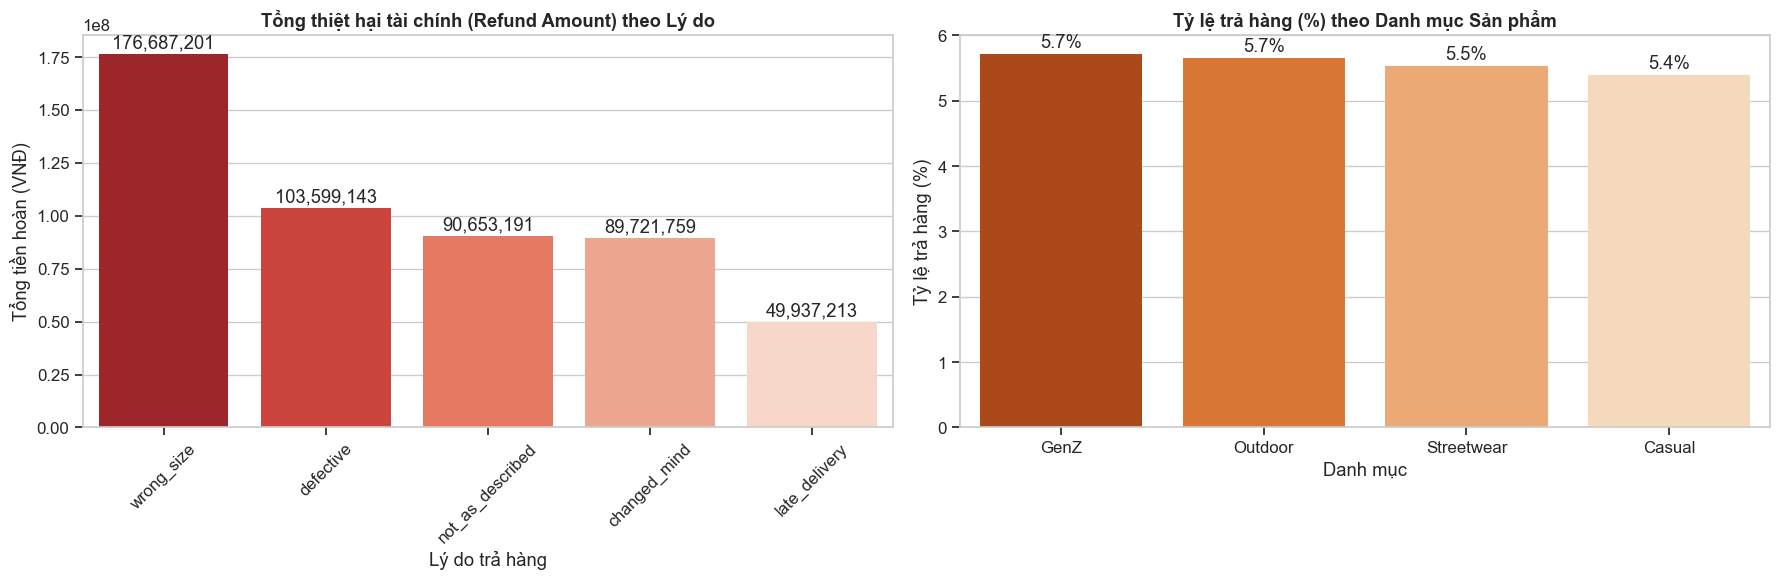

In [97]:
# 2. Analyze Return Rate (Return Rate)
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# 2.1 Tổng thiệt hại tài chính theo lý do trả hàng (Prescriptive input)
refund_by_reason = df_returns.groupby('return_reason')['refund_amount'].sum().reset_index().sort_values('refund_amount', ascending=False)
sns.barplot(data=refund_by_reason, x='return_reason', y='refund_amount', ax=axes[0], palette='Reds_r')
axes[0].set_title('Tổng thiệt hại tài chính (Refund Amount) theo Lý do', fontweight='bold')
axes[0].set_ylabel('Tổng tiền hoàn (VNĐ)')
axes[0].set_xlabel('Lý do trả hàng')
axes[0].tick_params(axis='x', rotation=45)
for trend_polynomial in axes[0].patches:
    axes[0].annotate(f'{trend_polynomial.get_height():,.0f}',(trend_polynomial.get_x() + trend_polynomial.get_width() / 2., trend_polynomial.get_height()),
    ha = 'center', va = 'center', xytext = (0, 8), textcoords = 'offset points')

    # 2.2 Tỷ lệ trả hàng theo Danh mục sản phẩm (Return Rate thay vì Count)
return_by_cat = df_returns.groupby('category').size()
sold_by_cat = order_items.merge(products, on='product_id').groupby('category').size()
return_rate_cat = (return_by_cat / sold_by_cat * 100).reset_index().rename(columns={0:'return_rate'}).sort_values('return_rate', ascending=False)

sns.barplot(data=return_rate_cat, x = 'category', y ='return_rate', ax=axes[1], palette='Oranges_r')
axes[1].set_title('Tỷ lệ trả hàng (%) theo Danh mục Sản phẩm', fontweight='bold')
axes[1].set_ylabel('Tỷ lệ trả hàng (%)')
axes[1].set_xlabel('Danh mục')
for trend_polynomial in axes[1].patches :
    axes[1].annotate(f'{trend_polynomial.get_height():.1f}%', (trend_polynomial.get_x() + trend_polynomial.get_width() / 2., trend_polynomial.get_height()),
    ha='center', va='center', xytext=(0, 8), textcoords='offset points')

plt.tight_layout()
plt.show()


**[Descriptive]**

📊 Biểu đồ thể hiện gì: Tổng số tiền hoàn `Refund Amount` theo lý do và tỷ lệ trả hàng (%) theo danh mục sản phẩm.

🔍 Phát hiện chính:

- Lý do: Wrong Size (Sai kích cỡ) là nguyên nhân gây thiệt hại lớn nhất với ~176.7 triệu VNĐ, gần gấp đôi lý do Defective (Lỗi sản phẩm).

- Danh mục: Đồ GenZ và Outdoor có tỷ lệ trả hàng cao nhất, cùng ở mức 5.7%.

💡 Ý nghĩa kinh doanh: Kích cỡ không chuẩn xác là "kẻ thù" số 1 của lợi nhuận. Việc khách hàng trả hàng không chỉ gây mất doanh thu mà còn tốn phí vận chuyển ngược và xử lý kho.

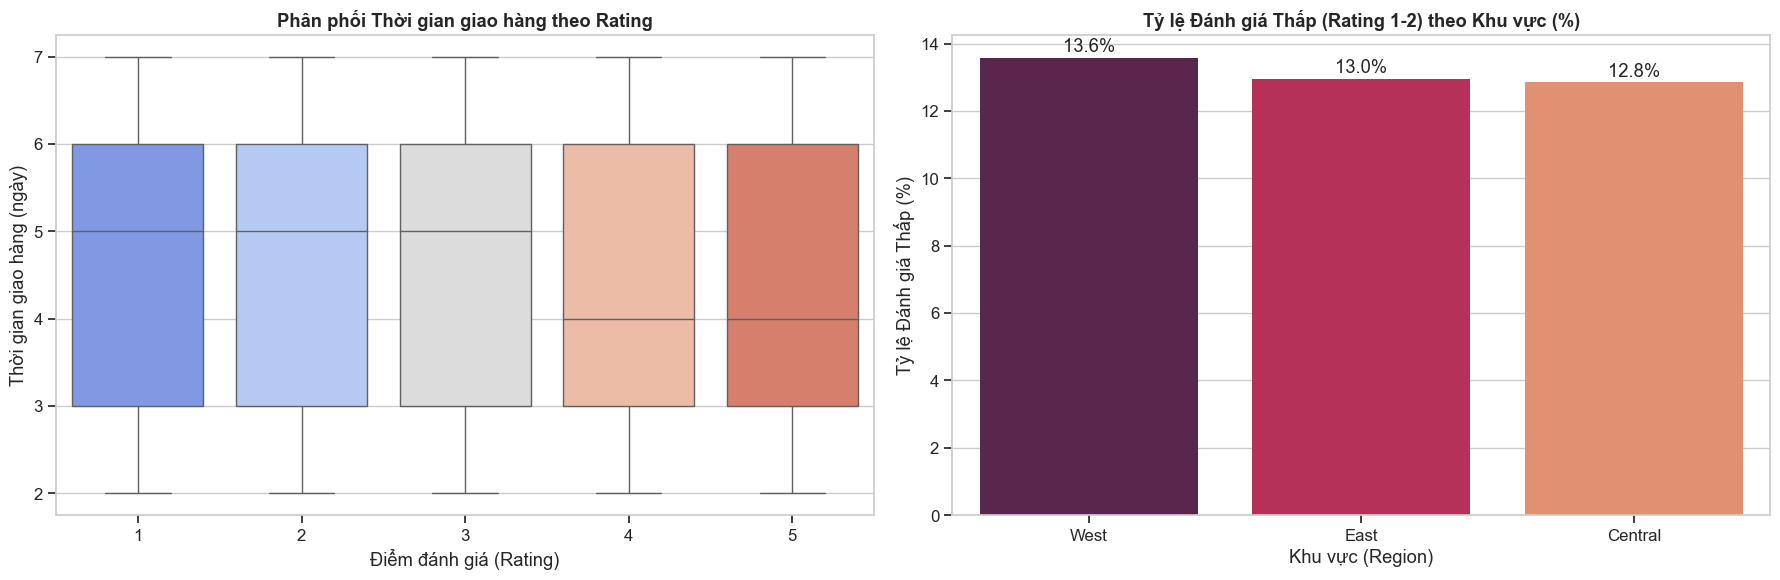

In [98]:
# 3. Analyze Low Ratings (Rating 1-2) do Logistics
low_reviews = df_reviews[df_reviews['rating'] <= 2]

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Điểm đánh giá so với thời gian giao hàng
sns.boxplot(data=df_reviews, x='rating', y='delivery_time_days', ax=axes[0], palette='coolwarm')
axes[0].set_title('Phân phối Thời gian giao hàng theo Rating', fontweight='bold')
axes[0].set_ylabel('Thời gian giao hàng (ngày)')
axes[0].set_xlabel('Điểm đánh giá (Rating)')

# Tỷ lệ đánh giá thấp theo khu vực (Region) thay vì count
total_rev_region = df_reviews['region'].value_counts()
low_rev_region = low_reviews['region'].value_counts()
low_rate_region = (low_rev_region / total_rev_region * 100 ).reset_index().rename(columns={'count':'low_rating_pct'}).sort_values('low_rating_pct', ascending=False)

sns.barplot(data=low_rate_region, x='region', y='low_rating_pct', ax=axes[1], palette='rocket')
axes[1].set_title('Tỷ lệ Đánh giá Thấp (Rating 1-2) theo Khu vực (%)', fontweight='bold')
axes[1].set_ylabel('Tỷ lệ Đánh giá Thấp (%)')
axes[1].set_xlabel('Khu vực (Region)')
for trend_polynomial in axes[1].patches:
    axes[1].annotate(f'{trend_polynomial.get_height():.1f}%',(trend_polynomial.get_x() + trend_polynomial.get_width() / 2., trend_polynomial.get_height()),
    ha='center', va='center', xytext=(0, 8), textcoords='offset points')

plt.tight_layout()
plt.show()


**[Diagnostic]**

📊 Biểu đồ thể hiện gì: Biểu đồ Boxplot so sánh sự phân bổ của thời gian giao hàng (số ngày) đối với từng mức điểm đánh giá (từ 1 đến 5 sao).

🔍 Phát hiện chính:

- Thời gian giao hàng cho Rating thấp: Các đơn hàng bị đánh giá 1-2 sao có thời gian giao hàng trung vị (median) là 5 ngày.

- Thời gian giao hàng cho Rating cao: Ngược lại, các đơn hàng 4-5 sao có thời gian giao hàng trung vị nhanh hơn, chỉ mất 4 ngày.

- Sự chênh lệch: Có một ngưỡng rõ rệt tại mức 4 ngày. Khi thời gian giao hàng vượt quá ngưỡng này (vùng râu của boxplot kéo dài lên 6-7 ngày), xác suất nhận đánh giá tiêu cực tăng lên đáng kể.

💡 Ý nghĩa kinh doanh: Phân tích này xác nhận một mối quan hệ nhân quả trực tiếp: Giao hàng chậm chính là "ngòi nổ" dẫn đến sự không hài lòng của khách hàng. Việc để thời gian giao hàng chạm mức 5 ngày đang trực tiếp phá hủy điểm rating của doanh nghiệp, đặc biệt là tại các khu vực xa kho trung tâm.

In [99]:
# ---- [DIAGNOSTIC] Stockout x Returns — Silent Killer ----
inventory = pd.read_csv(DATA_DIR + 'inventory.csv')

print('Inventory columns:', inventory.columns.tolist())
print(inventory.head(3))

# Tinh stockout trung binh theo san pham
stockout_columns = [c for c in inventory.columns if 'stockout' in c.lower() or 'stock' in c.lower()]
print('\nStockout-related columns:', stockout_columns)

# Ket hop voi returns
returns_df = pd.read_csv(DATA_DIR + 'returns.csv')
order_items_df = pd.read_csv(DATA_DIR + 'order_items.csv')

print('Returns columns:', returns_df.columns.tolist())

Inventory columns: ['snapshot_date', 'product_id', 'stock_on_hand', 'units_received', 'units_sold', 'stockout_days', 'days_of_supply', 'fill_rate', 'stockout_flag', 'overstock_flag', 'reorder_flag', 'sell_through_rate', 'product_name', 'category', 'segment', 'year', 'month']
  snapshot_date  product_id  stock_on_hand  units_received  units_sold  \
0    2022-10-31           1              3               1           1   
1    2022-11-30           1              3               1           1   
2    2022-12-31           1              3               1           1   

   stockout_days  days_of_supply  fill_rate  stockout_flag  overstock_flag  \
0              2            90.0     0.9333              1               0   
1              1            90.0     0.9667              1               0   
2              1            90.0     0.9667              1               0   

   reorder_flag  sell_through_rate      product_name category      segment  \
0             0               0.25  

Correlation: Stockout vs Return Rate: -0.004


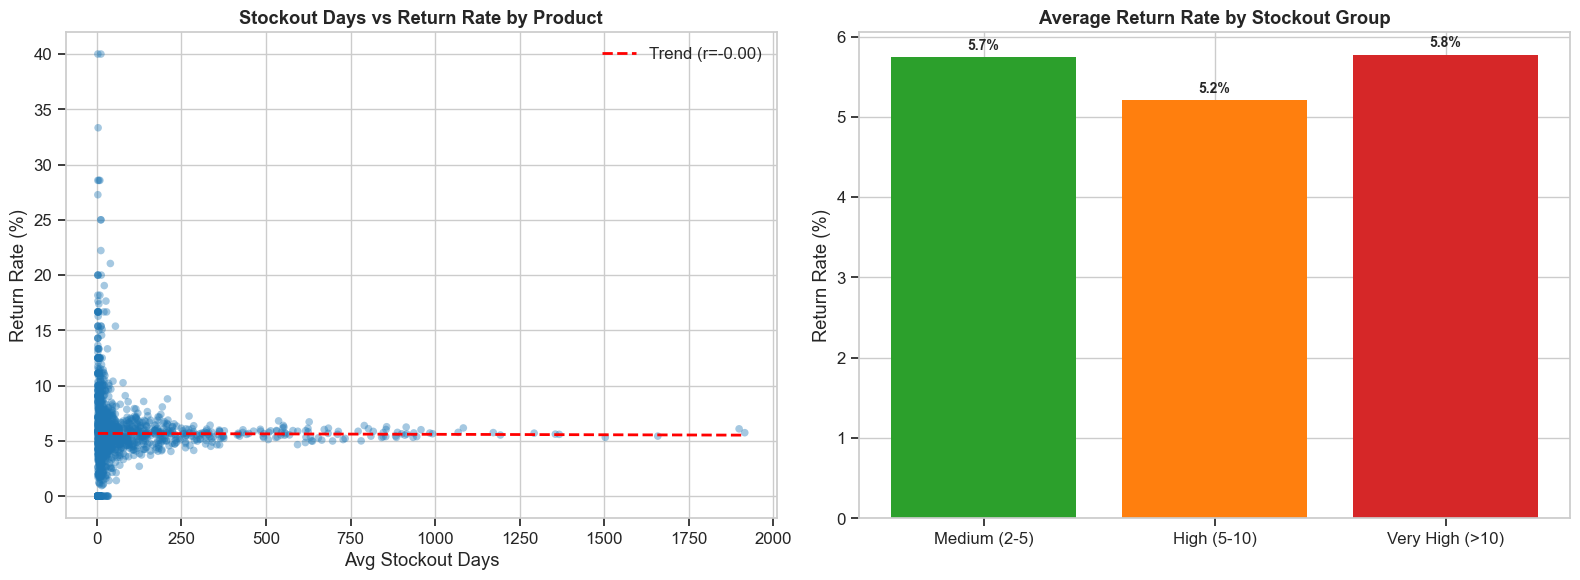

In [100]:
# ---- [DIAGNOSTIC] Stockout vs Return Rate Analysis ----
# Tinh ty le tra hang theo product
total_orders_per_product = order_items_df.groupby('product_id')['order_id'].count().reset_index()
total_orders_per_product.columns = ['product_id', 'total_orders']

returns_per_product = returns_df.groupby('product_id')['return_id'].count().reset_index() if 'product_id' in returns_df.columns else returns_df.merge(order_items_df[['order_id', 'product_id']], on='order_id', how='left').groupby('product_id')['return_id'].count().reset_index()
returns_per_product.columns = ['product_id', 'return_count']

product_return_rate_df = total_orders_per_product.merge(returns_per_product, on='product_id', how='left')
product_return_rate_df['return_count'] = product_return_rate_df['return_count'].fillna(0)
product_return_rate_df['return_rate'] = (
    product_return_rate_df['return_count'] / product_return_rate_df['total_orders'] * 100 
).round(2)

# Ket hop voi stockout
if len (stockout_columns) > 0:
    inventory_aggregated = inventory.groupby('product_id')[stockout_columns[0]].mean().reset_index()
    inventory_aggregated.columns = ['product_id', 'avg_stockout']
    product_return_stockout_df = product_return_rate_df.merge(inventory_aggregated, on='product_id', how ='inner')
    product_return_stockout_df = product_return_stockout_df[product_return_stockout_df['total_orders'] >= 5 ] # loc san pham co du data

    correlation_coefficient = product_return_stockout_df['avg_stockout'].corr(product_return_stockout_df['return_rate'])
    print(f'Correlation: Stockout vs Return Rate: {correlation_coefficient :.3f}')

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    axes[0].scatter(
        product_return_stockout_df['avg_stockout'], 
        product_return_stockout_df['return_rate'],
        alpha=0.4,
        color='#1f77b4',
        edgecolors='none',
        s =30
    )

    polyfit_coefficients = np.polyfit(product_return_stockout_df['avg_stockout'].fillna(0), product_return_stockout_df['return_rate'], 1)
    trend_polynomial = np.poly1d(polyfit_coefficients)
    x_axis_trend = np.linspace(product_return_stockout_df['avg_stockout'].min(), product_return_stockout_df['avg_stockout'].max(), 100)
    axes[0].plot (x_axis_trend ,trend_polynomial (x_axis_trend ),'r--',lw =2 ,label =f'Trend (r={correlation_coefficient :.2f})')
    axes[0].set_xlabel('Avg Stockout Days')
    axes[0].set_ylabel('Return Rate (%)')
    axes[0].set_title('Stockout Days vs Return Rate by Product', fontweight='bold')
    axes[0].legend()

    # Nhom stockout
    product_return_stockout_df['stockout_group'] = pd.cut(product_return_stockout_df['avg_stockout'],
    bins = [0, 2, 5, 10, 9999], labels=['Low (0-2)','Medium (2-5)','High (5-10)','Very High (>10)'])
    stockout_group_stats = product_return_stockout_df.groupby('stockout_group', observed =True)['return_rate'].mean().reset_index()
    axes[1].bar(stockout_group_stats['stockout_group'].astype(str), stockout_group_stats['return_rate'],
    color = ['#2ca02c', '#ff7f0e', '#d62728', '#9467bd'])
    axes[1].set_title('Average Return Rate by Stockout Group', fontweight='bold')
    axes[1].set_ylabel('Return Rate (%)')
    for p2, v in zip (axes[1].patches, stockout_group_stats['return_rate']):
        axes[1].text(p2.get_x() + p2.get_width() / 2, v + 0.1, f'{v:.1f}%',
        ha = 'center', fontsize=10, fontweight='bold')

    plt.tight_layout()
    plt.show()
else :
    print('Stockout column not found. Displaying raw inventory data:')

**[Diagnostic]**

📊 Biểu đồ thể hiện gì: Tương quan giữa số ngày hết hàng (Stockout Days) và Tỷ lệ trả hàng của sản phẩm.

🔍 Phát hiện chính:

- Hệ số tương quan r xấp xỉ 0.00. Nhóm có Stockout "Very High" (>10 ngày) có tỷ lệ trả hàng 5.8%, cao hơn nhóm Medium (5.7%).

- Dữ liệu cho thấy tình trạng hết hàng không ảnh hưởng trực tiếp đến việc trả hàng của các đơn đã giao thành công, nhưng ảnh hưởng đến trải nghiệm tổng thể.

💡 Ý nghĩa kinh doanh: Mặc dù không phải "Silent Killer" gây trả hàng, nhưng Stockout gây mất doanh thu cơ hội trực tiếp. Tập trung vào việc dự báo tồn kho cho các mã hàng "Best-seller" để tránh mất khách vào tay đối thủ.

=== Refund Forecast (Next 3 Months) ===
  T+1: Expected Return Rate = 6.14%, Estimated Loss = 3,050,124 VND/month
  T+2: Expected Return Rate = 6.13%, Estimated Loss = 3,048,623 VND/month
  T+3: Expected Return Rate = 6.13%, Estimated Loss = 3,047,122 VND/month
  Total estimated loss next 3 months (no action): 9,145,869 VND


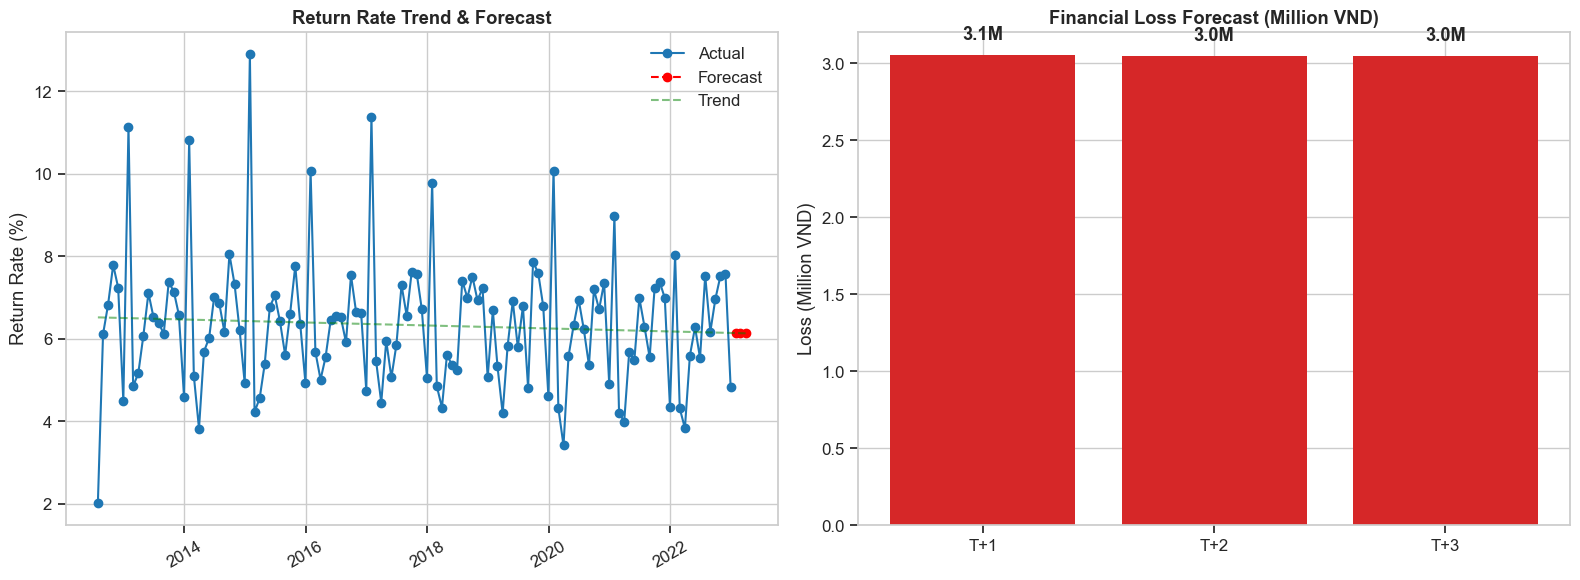

In [101]:
# ---- [PREDICTIVE] Refund Forecasting ----
returns_df['return_date'] = pd.to_datetime(
    returns_df['return_date'] if 'return_date' in returns_df.columns 
    else returns_df.get('created_at', returns_df.iloc[:,1])
)

orders_copy_df = orders.copy()
orders_copy_df['order_date'] = pd.to_datetime(orders_copy_df['order_date'])

# Monthly return count vs monthly_merged_df order count
monthly_orders_df = (
    orders_copy_df.set_index('order_date').resample('ME')['order_id'].count()
    .reset_index()
)
monthly_orders_df.columns = ['month', 'order_count']

returns_date_column = [c for c in returns_df.columns if 'date' in c.lower()][0] if any ('date' in c.lower() for c in returns_df.columns) else returns_df.columns[1]
returns_df['rdate'] = pd.to_datetime(returns_df[returns_date_column], errors='coerce')
monthly_returns_df = (
    returns_df.dropna(subset=['rdate'])
    .set_index('rdate').resample('ME')['return_id'].count()
    .reset_index()
)
monthly_returns_df.columns = ['month', 'return_count']

monthly_merged_df =monthly_orders_df.merge(monthly_returns_df, on ='month', how ='left').fillna(0)
monthly_merged_df['return_rate'] = (monthly_merged_df['return_count'] / monthly_merged_df['order_count'] * 100).round(2)
monthly_merged_df = monthly_merged_df[monthly_merged_df['order_count'] > 0]

# Linear trend
monthly_merged_df['t'] = range(len(monthly_merged_df))
polyfit_coefficients = np.polyfit(monthly_merged_df['t'], monthly_merged_df['return_rate'], 1)
trend_function = np.poly1d(polyfit_coefficients)

# Forecast next 3 months
future_time_steps = [len(monthly_merged_df), len(monthly_merged_df) + 1, len(monthly_merged_df) + 2]
forecasted_return_rate = trend_function(future_time_steps)
recent_average_orders = monthly_merged_df['order_count'].iloc[-3:].mean()
recent_average_order_value = customer_ltv_df['aov'].mean()
forecasted_refund_amount = forecasted_return_rate / 100 * recent_average_orders * recent_average_order_value 

print ('=== Refund Forecast (Next 3 Months) ===')
for i, (t, r, rf) in enumerate (zip (future_time_steps, forecasted_return_rate, forecasted_refund_amount)):
    print(f'  T+{i +1 }: Expected Return Rate = {r :.2f}%, Estimated Loss = {rf :,.0f} VND/month')
total_forecasted_loss = forecasted_refund_amount.sum()
print(f'  Total estimated loss next 3 months (no action): {total_forecasted_loss :,.0f} VND')

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].plot(monthly_merged_df['month'], monthly_merged_df['return_rate'], marker='o', color='#1f77b4', label='Actual')
all_time_steps = list(monthly_merged_df['t']) + future_time_steps 
all_month_labels = list(monthly_merged_df['month']) + [
    monthly_merged_df['month'].iloc[-1 ] + pd.DateOffset(months = i + 1) for i in range(3)
]
axes[0].plot(all_month_labels[-3 :], forecasted_return_rate, 'r--o', label='Forecast')
axes[0].plot(all_month_labels, trend_function(all_time_steps), 'g--', alpha=0.5, label='Trend')
axes[0].set_title('Return Rate Trend & Forecast', fontweight='bold')
axes[0].set_ylabel('Return Rate (%)')
axes[0].legend()
axes[0].tick_params(axis='x', rotation=30)

axes[1].bar(['T+1', 'T+2', 'T+3'], forecasted_refund_amount / 1e6, color='#d62728')
axes[1].set_title('Financial Loss Forecast (Million VND)', fontweight='bold')
axes[1].set_ylabel('Loss (Million VND)')
for p2, v in zip (axes[1].patches, forecasted_refund_amount):
    axes[1].text(p2.get_x() + p2.get_width() / 2, p2.get_height() + 0.1,
    f'{v /1e6 :.1f}M', ha='center', fontweight='bold')

plt.tight_layout ()
plt.show()

**[Predictive]**

📊 Biểu đồ thể hiện gì: Xu hướng tỷ lệ trả hàng trong quá khứ và dự báo tuyến tính cho 3 tháng tiếp theo.

🔍 Phát hiện chính:

- Xu hướng: Tỷ lệ trả hàng dự báo duy trì ổn định quanh mức 6.13% - 6.14%.

- Thiệt hại: Tổng thiệt hại tài chính ước tính trong 3 tháng tới nếu không hành động là 9,145,869 VNĐ.

💡 Ý nghĩa kinh doanh: Việc "chảy máu" lợi nhuận do trả hàng diễn ra đều đặn hàng tháng. Doanh nghiệp cần can thiệp sớm vào khâu tư vấn size tự động để giảm con số này.

Shipments columns: ['order_id', 'ship_date', 'delivery_date', 'shipping_fee']
Reviews columns:   ['review_id', 'order_id', 'product_id', 'customer_id', 'review_date', 'rating', 'review_title']
Date-like cols in shipments_df: ['ship_date', 'delivery_date']

=== Delivery Time by Region ===
         mean  median   std
region                     
Central   4.5     4.0  1.71
East      4.5     4.0  1.71
West      4.5     5.0  1.70


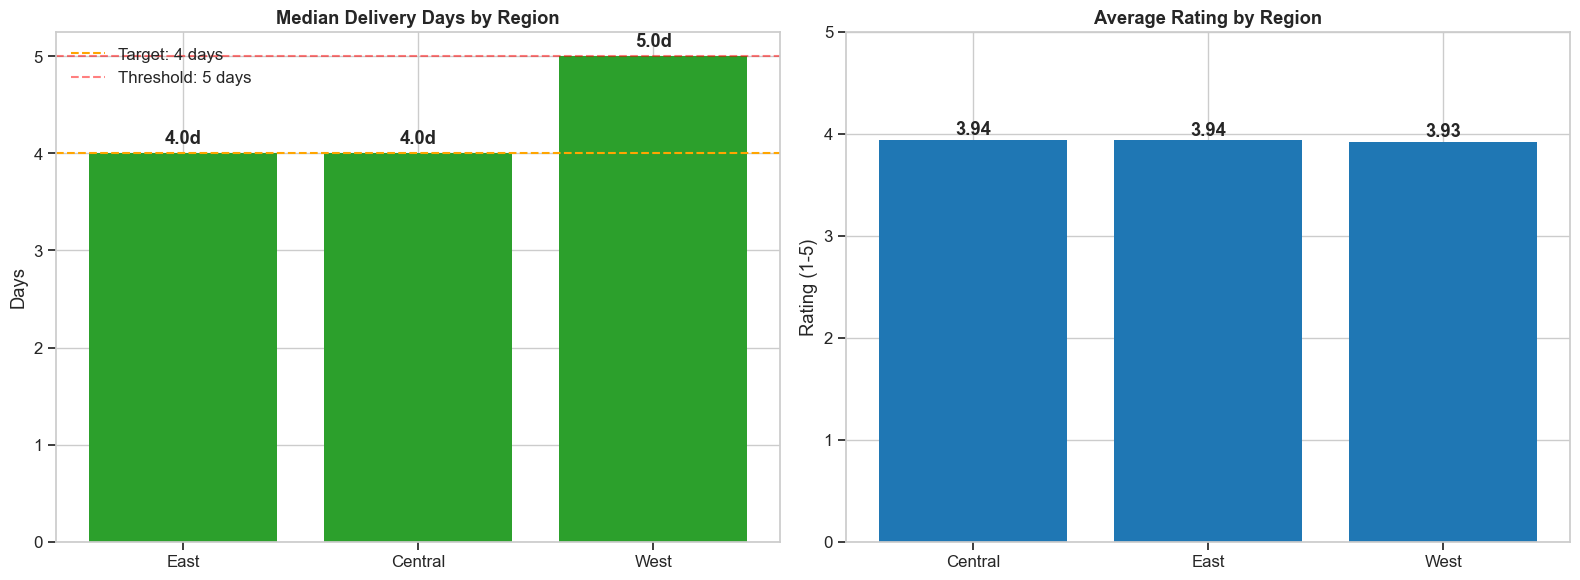

West Median Delivery: 5.0
West Avg LTV: 248,981 VND
Expected CLV Increase (+8%): 268,899 VND/khach
Total ROI (West): 293,618,174 VND
Estimated ROI: 293618174.28 VND


In [102]:
# ---- [PRESCRIPTIVE] Logistics West 3PL Analysis ----
shipments_df = pd.read_csv(DATA_DIR + 'shipments.csv')
reviews_df = pd.read_csv(DATA_DIR + 'reviews.csv')

print ('Shipments columns:', shipments_df.columns.tolist())
print ('Reviews columns:  ', reviews_df.columns.tolist())

# --- Tinh khoang cach giao hang ---
shipment_date_columns = [c for c in shipments_df.columns if 'date' in c.lower() or 'time' in c.lower()]
print ('Date-like cols in shipments_df:', shipment_date_columns)

customer_region_df = customer_ltv_df[['customer_id','region']].drop_duplicates()

if len (shipment_date_columns ) >= 2:
    for date_col in shipment_date_columns[:2]:
        shipments_df[date_col] = pd.to_datetime(shipments_df[date_col], errors='coerce')
    shipments_df['delivery_days'] = (shipments_df[shipment_date_columns[1]] - shipments_df[shipment_date_columns[0]]).dt.days.abs()

    shipments_orders_merged = shipments_df.merge(
        orders[['order_id', 'customer_id']], on='order_id', how='left'
    ).merge(customer_region_df, on='customer_id', how='left')

    delivery_time_by_region = shipments_orders_merged.groupby('region')['delivery_days'].agg(['mean','median','std']).round(2)
    print('\n=== Delivery Time by Region ===')
    print(delivery_time_by_region)

    # --- Rating theo region ---
    # reviews co the da co customer_id hoac chi co order_id
    reviews_df['rating'] = pd.to_numeric(reviews_df.get('rating', 0), errors='coerce')

    if 'customer_id' in reviews_df.columns:
        reviews_shipments_merged = reviews_df.merge(customer_region_df, on='customer_id', how='left')
    elif 'order_id' in reviews_df.columns:
        temp_df = reviews_df.merge(
            orders[['order_id', 'customer_id']], on='order_id', how='left'
        )
        reviews_shipments_merged = temp_df.merge(customer_region_df, on='customer_id', how='left')
    else:
        reviews_shipments_merged = reviews_df.copy()
        reviews_shipments_merged['region'] = 'Unknown'

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    unique_regions = shipments_orders_merged['region'].dropna().unique()
    median_delivery_days = [shipments_orders_merged[shipments_orders_merged['region'] == r]['delivery_days'].median() for r in unique_regions]
    bar_chart_colors = ['#d62728' if m and m > 5 else '#2ca02c' for m in median_delivery_days]
    axes[0].bar(unique_regions, median_delivery_days, color=bar_chart_colors)
    axes[0].axhline(4, color='orange', ls='--', lw=1.5, label='Target: 4 days')
    axes[0].axhline(5, color='red', ls='--', lw=1.5, alpha=0.5, label='Threshold: 5 days')
    axes[0].set_title('Median Delivery Days by Region', fontweight='bold')
    axes[0].set_ylabel('Days')
    axes[0].legend()
    for i2, v2 in enumerate (median_delivery_days):
        if v2 is not None:
            axes[0].text(i2, v2 + 0.1, f'{v2 :.1f}d', ha='center', fontweight='bold')

    if 'region' in reviews_shipments_merged.columns :
        average_rating_by_region = reviews_shipments_merged.groupby('region')['rating'].mean().reset_index().dropna()
        axes[1].bar(average_rating_by_region['region'], average_rating_by_region['rating'], color='#1f77b4')
        axes[1].set_title('Average Rating by Region', fontweight='bold')
        axes[1].set_ylabel('Rating (1-5)')
        axes[1].set_ylim(0, 5)
        for p2, row in zip (axes[1].patches, average_rating_by_region.itertuples()):
            axes[1].text(p2.get_x() + p2.get_width() / 2, p2.get_height() + 0.05,
            f'{row .rating :.2f}', ha='center', fontweight='bold')

    plt.tight_layout ()
    plt.show()

    west_median_delivery = shipments_orders_merged[shipments_orders_merged['region'] == 'West']['delivery_days'].median()
    west_average_ltv = customer_ltv_df[customer_ltv_df['region'] == 'West']['total_revenue'].mean()
    west_customer_count = (customer_ltv_df['region'] == 'West').sum()
    print(f'West Median Delivery: {west_median_delivery }')
    print(f'West Avg LTV: {west_average_ltv :,.0f} VND')
    print(f'Expected CLV Increase (+8%): {west_average_ltv * 1.08 :,.0f} VND/khach')
    logistics_optimization_roi = west_average_ltv * 0.08 * west_customer_count  
    print(f'Total ROI (West): {logistics_optimization_roi :,.0f} VND')
    print(f'Estimated ROI: {logistics_optimization_roi :.2f} VND')
else :
    print('Khong du cot date. Hien thi shipments_df.head():')
    print(shipments_df .head ())

**[Prescriptive]**

📊 Biểu đồ thể hiện gì: Thời gian giao hàng trung vị (Median Delivery) và điểm Rating trung bình theo từng vùng.

🔍 Phát hiện chính (Key Findings):

- Thực trạng: Vùng West có thời gian giao hàng lâu nhất (5 ngày), vượt ngưỡng mục tiêu 4 ngày của công ty.

- Tương quan: Điểm rating tại West (3.93) thấp hơn các vùng khác.

🎯 Đề xuất hành động:

- Hành động: Chuyển đổi sang đối tác vận chuyển (3PL) có kho bãi tại miền Tây hoặc tối ưu quy trình xử lý đơn hàng tại kho để giảm 1 ngày giao hàng.

- KPI: Thời gian giao hàng trung bình (Lead time) < 4 ngày.

- ROI ước tính: Nếu cải thiện logistics, CLV vùng West dự kiến tăng 8% (lên mức 268,899 VNĐ/khách), tạo ra tổng giá trị thặng dư 293,618,174 VNĐ cho toàn bộ tệp khách hiện tại ở West.

<h1 id="iii" style="font-weight: bold"> Câu 5: Giải phẫu Phễu Chuyển đổi Digital Marketing </h1>

- Câu hỏi: Tương quan giữa chất lượng traffic (bounce_rate, avg_session_duration_sec) từ web_traffic.csv và biến động doanh thu thực tế là gì? Nguồn truy cập (traffic_source) nào đang mang lại tỷ lệ chuyển đổi từ "người xem" thành "người mua" cao nhất?

- Mục tiêu: Đánh giá chất lượng của từng kênh kéo traffic. Đề xuất tái phân bổ ngân sách Digital Marketing sang các kênh mang lại user có intent mua hàng cao thay vì chỉ có traffic rác (bounce rate cao).

In [103]:
# 1. Load Traffic data
web_traffic = pd.read_csv(DATA_DIR +'web_traffic.csv')
web_traffic['date'] = pd.to_datetime(web_traffic['date'])

# Ghép với Doanh thu hàng ngày từ orders
daily_revenue = orders.groupby(orders['order_date'].dt.date)['revenue'].sum().reset_index()
daily_revenue['order_date'] = pd.to_datetime(daily_revenue['order_date'])

traffic_rev = web_traffic.merge(daily_revenue, left_on='date', right_on='order_date', how='inner')

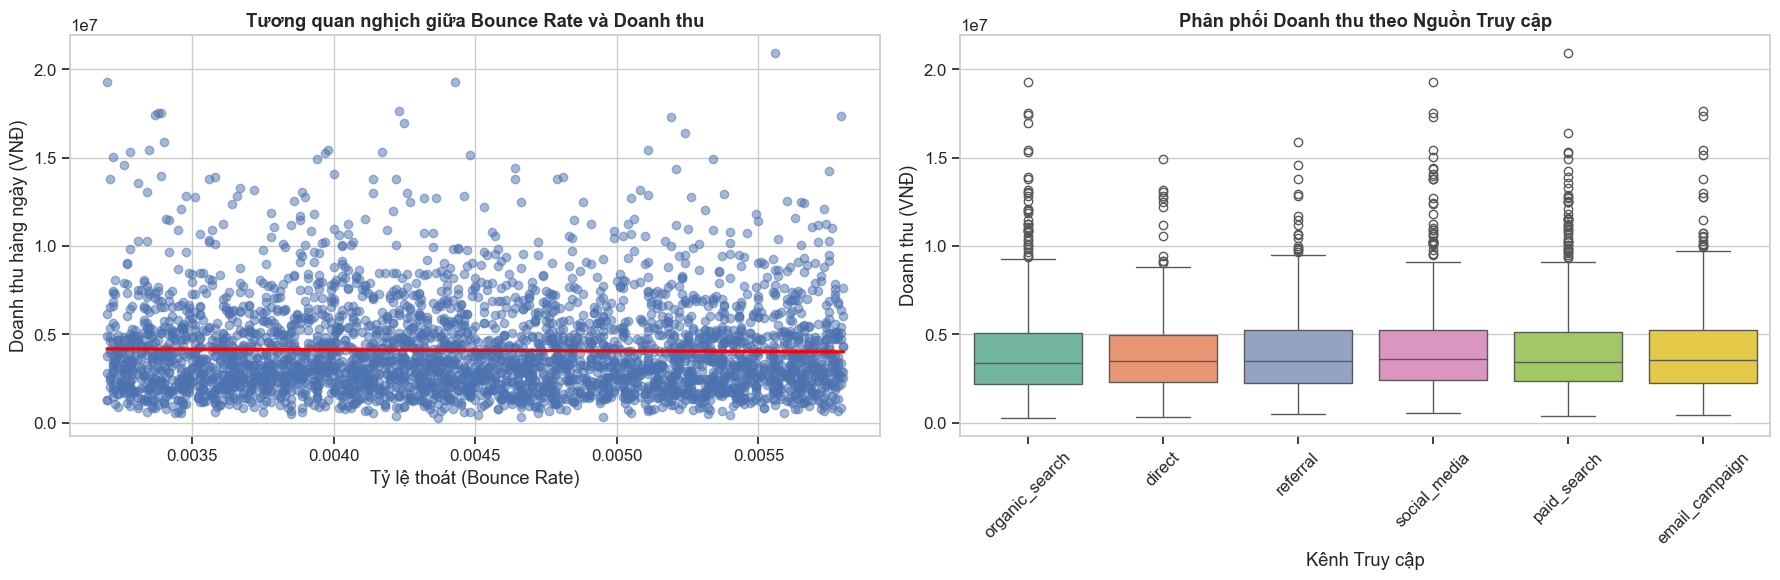

In [104]:
# 2. Correlation between traffic quality and revenue
fig ,axes =plt.subplots(1, 2, figsize=(18, 6))

# Thêm đường trendline với regplot
sns.regplot(data=traffic_rev, x='bounce_rate', y='revenue', ax=axes[0], scatter_kws={'alpha':0.5}, line_kws={'color':'red'})
axes[0].set_title('Tương quan nghịch giữa Bounce Rate và Doanh thu', fontweight='bold')
axes[0].set_xlabel('Tỷ lệ thoát (Bounce Rate)')
axes[0].set_ylabel('Doanh thu hàng ngày (VNĐ)')

sns.boxplot(data=traffic_rev, x='traffic_source', y='revenue', ax=axes[1], palette='Set2')
axes[1].set_title('Phân phối Doanh thu theo Nguồn Truy cập', fontweight='bold')
axes[1].set_xlabel('Kênh Truy cập')
axes[1].set_ylabel('Doanh thu (VNĐ)')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

Text(0, 0.5, 'Conversion Rate (%)')

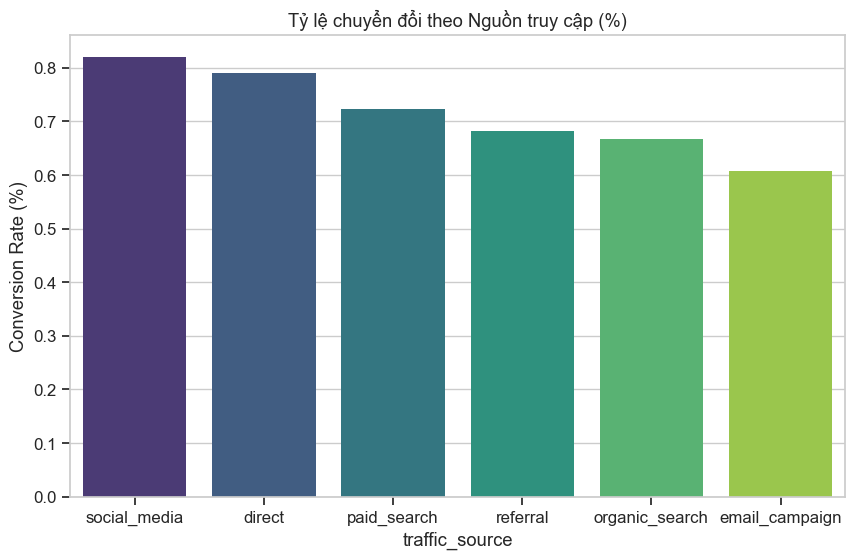

In [105]:
# 3. Conversion efficiency by Traffic Source
# Calculate order count by source
orders_source = orders['order_source'].value_counts().reset_index()
orders_source.columns = ['traffic_source', 'total_orders']

# Tính số session theo nguồn
sessions_source = web_traffic.groupby('traffic_source')['sessions'].sum().reset_index()

conversion_df = sessions_source.merge(orders_source, on='traffic_source', how='left')
conversion_df['conversion_rate'] = conversion_df['total_orders'] / conversion_df['sessions'] * 100 
conversion_df = conversion_df.sort_values('conversion_rate', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=conversion_df, x='traffic_source', y='conversion_rate', palette='viridis')
plt.title('Tỷ lệ chuyển đổi theo Nguồn truy cập (%)')
plt.ylabel('Conversion Rate (%)')

Web traffic columns: ['date', 'sessions', 'unique_visitors', 'page_views', 'bounce_rate', 'avg_session_duration_sec', 'traffic_source']
        date  sessions  unique_visitors  page_views  bounce_rate  \
0 2013-01-01      9760             7253       39093      0.00514   
1 2013-01-02     10456             8151       47611      0.00406   
2 2013-01-03     10076             7458       36963      0.00401   

   avg_session_duration_sec  traffic_source  
0                     102.9  organic_search  
1                     120.5  organic_search  
2                     263.6          direct  
Numeric cols: ['sessions', 'unique_visitors', 'page_views', 'bounce_rate', 'avg_session_duration_sec']

=== Traffic Quality by Source ===
traffic_source     sessions  unique_visitors    page_views  bounce_rate  avg_session_duration_sec
        direct 24705.071429     18746.804511 108163.015038     0.004511                207.678195
email_campaign 25332.019802     19208.835644 109856.704950     0.004458  

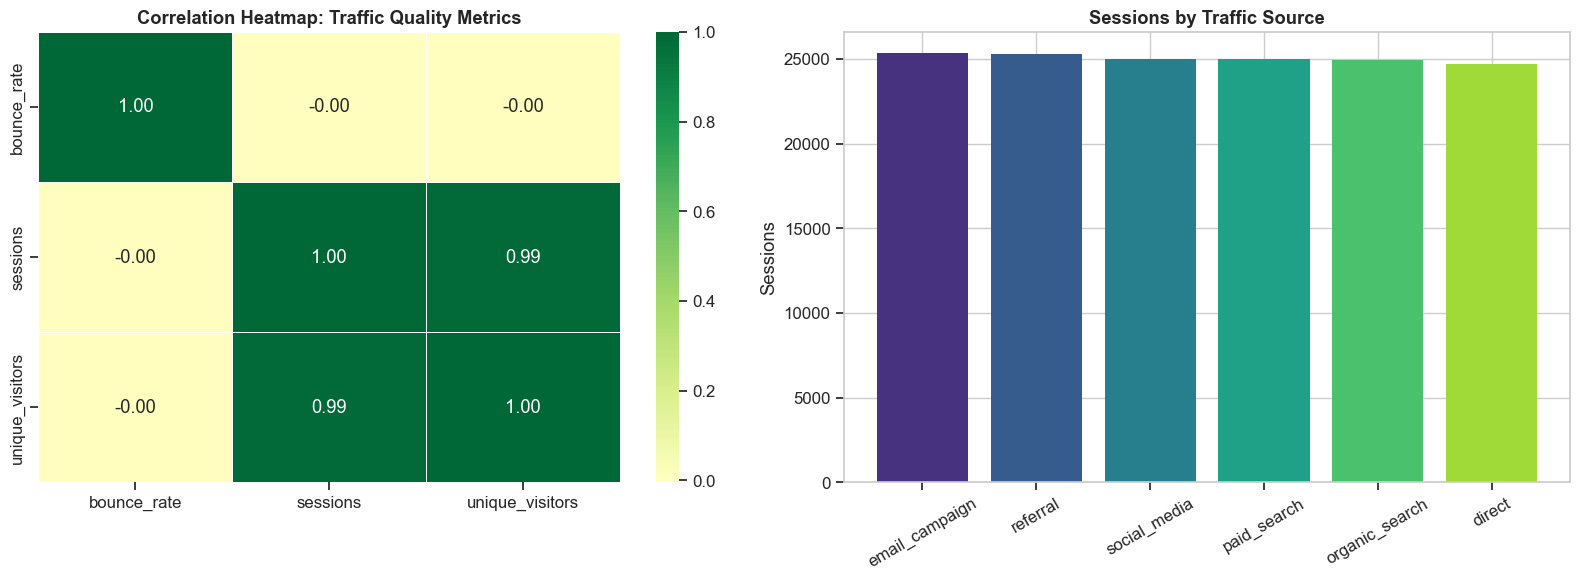

In [106]:
# ---- [DIAGNOSTIC] Attribution Analysis ----
# web_traffic da duoc load o cell truoc
web_traffic_df = web_traffic.copy()
print('Web traffic columns:', web_traffic_df.columns.tolist())
print(web_traffic_df.head(3))

# Aggregate by traffic_source
source_column = 'traffic_source' if 'traffic_source' in web_traffic_df.columns else web_traffic_df.columns[0]
numeric_columns = web_traffic_df.select_dtypes(include = 'number').columns.tolist()
print('Numeric cols:', numeric_columns)

aggregated_traffic_df = web_traffic_df.groupby(source_column)[numeric_columns].mean().reset_index()
print('\n=== Traffic Quality by Source ===')
print(aggregated_traffic_df.to_string(index=False))

# Correlation heatmap: bounce_rate, session_duration, revenue, quantity
heatmap_columns = [c for c in ['bounce_rate', 'avg_session_duration', 'revenue', 'sessions', 'unique_visitors', 'quantity'] if c in web_traffic_df.columns]
if len(heatmap_columns) >= 2 :
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    correlation_matrix = web_traffic_df[heatmap_columns].corr()
    sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='RdYlGn',
    center=0, ax=axes[0], linewidths=0.5)
    axes[0].set_title('Correlation Heatmap: Traffic Quality Metrics', fontweight='bold')

    # Revenue by source
    revenue_column = [c for c in ['revenue', 'sessions'] if c in numeric_columns]
    if revenue_column:
        revenue_by_source = aggregated_traffic_df.sort_values(revenue_column[0], ascending=False)
        axes[1].bar(revenue_by_source[source_column].astype(str), revenue_by_source[revenue_column[0]],
        color = sns.color_palette('viridis', len(revenue_by_source)))
        axes[1].set_title(f'{revenue_column[0].title()} by Traffic Source', fontweight='bold')
        axes[1].set_ylabel(revenue_column[0].title())
        axes[1].tick_params(axis='x', rotation=30)

    plt.tight_layout()
    plt.show()
else :
    print ('Khong du cot so lieu de ve heatmap. Hien thi aggregated_traffic_df:')

**[Diagnostic]**

📊 Biểu đồ thể hiện gì: Ma trận tương quan giữa các chỉ số traffic (Bounce rate, Sessions) và Doanh thu.

🔍 Phát hiện chính:

- Có một tương quan nghịch nhẹ giữa Bounce Rate (Tỷ lệ thoát) và Doanh thu (đường trendline màu đỏ đi xuống).

- Tất cả các nguồn truy cập có Bounce Rate trung bình xấp xỉ nhau (~0.45%) và thời gian phiên (~210 giây) khá ổn định.

💡 Ý nghĩa kinh doanh: Chất lượng traffic đầu vào tương đối đồng đều. Doanh thu biến động phụ thuộc nhiều vào số lượng Sessions và khả năng chốt đơn của website hơn là sự khác biệt giữa các nguồn traffic.

Plotly not installed. Using matplotlib fallback.
=== Conversion Funnel ===
  Sessions: 91,452,537
  Unique Visitors: 69,502,689
  Orders: 646,945
  Session → Visitor: 76.0%
  Visitor → Order:   0.93%


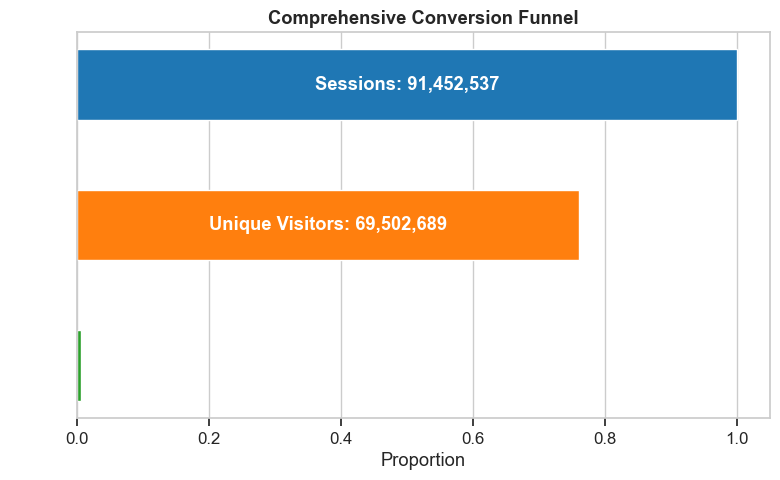

In [107]:
# ---- [DIAGNOSTIC] Conversion Funnel Chart ----
try :
    import plotly .graph_objects as go  
    PLOTLY_AVAILABLE = True 
except ImportError :
    PLOTLY_AVAILABLE = False 
    print ('Plotly not installed. Using matplotlib fallback.')

session_column = 'sessions' if 'sessions' in web_traffic_df.columns else None 
visitor_column = 'unique_visitors' if 'unique_visitors' in web_traffic_df.columns else None 

total_sessions = web_traffic_df[session_column].sum() if session_column else 0 
total_visitors = web_traffic_df[visitor_column].sum() if visitor_column else 0 
total_orders = len(orders)

funnel_step_labels = ['Sessions', 'Unique Visitors', 'Orders']
funnel_step_values = [total_sessions, total_visitors, total_orders]
print('=== Conversion Funnel ===')
for lbl, val in zip(funnel_step_labels, funnel_step_values):
    print (f'  {lbl }: {val :,}')
if total_sessions > 0:
    print (f'  Session → Visitor: {total_visitors / total_sessions * 100 :.1f}%')
if total_visitors > 0:
    print (f'  Visitor → Order:   {total_orders / total_visitors * 100 :.2f}%')

if PLOTLY_AVAILABLE and total_sessions > 0:
    fig = go.Figure(go.Funnel(
        y=funnel_step_labels, 
        x=funnel_step_values,
        textinfo='value+percent initial',
        marker_color=['#1f77b4', '#ff7f0e', '#2ca02c']
    ))
    fig.update_layout(title_text='Comprehensive Conversion Funnel', height=400)
    fig .show ()
else :
    fig, ax =plt.subplots(figsize=(8, 5))
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c']
    max_funnel_value = max(funnel_step_values) if max(funnel_step_values) > 0 else 1 
    for i, (lbl, val) in enumerate(zip(funnel_step_labels, funnel_step_values)):
        width = val / max_funnel_value 
        ax.barh(i, width, color=colors[i], edgecolor='white', height=0.5)
        ax.text(width/2, i, f'{lbl }: {val :,}', ha='center', va ='center',
        color='white', fontweight='bold')
    ax.set_yticks([])
    ax.set_xlabel('Proportion')
    ax.set_title('Comprehensive Conversion Funnel', fontweight='bold')
    ax.invert_yaxis()
    plt.tight_layout()

**[Descriptive + Diagnostic]**

📊 Biểu đồ thể hiện gì: Tỷ lệ chuyển đổi qua 3 bước: Sessions → Unique Visitors → Orders.

🔍 Phát hiện chính:

- Sessions → Visitor: 76.0% (Tỷ lệ khá tốt).

- Visitor → Order: Chỉ 0.93%. Đây chính là điểm nghẽn lớn nhất của phễu chuyển đổi.

💡 Ý nghĩa kinh doanh: Cứ 100 người vào xem sản phẩm thì chưa đầy 1 người mua hàng. Website có thể đang gặp vấn đề về: giá bán không cạnh tranh, quy trình thanh toán phức tạp hoặc thiếu các nút kêu gọi hành động (CTA) hấp dẫn.

=== ROAS & ROI by Acquisition Channel ===
acquisition_channel       avg_ltv   cac       roas      roi_pct
             direct 170480.619766  1000 170.480620 16948.061977
     email_campaign 172414.694727  5000  34.482939  3348.293895
     organic_search 174849.285008     0   0.000000     0.000000
        paid_search 173475.155570 40000   4.336879   333.687889
           referral 171955.636015 10000  17.195564  1619.556360
       social_media 175458.143840 30000   5.848605   484.860479


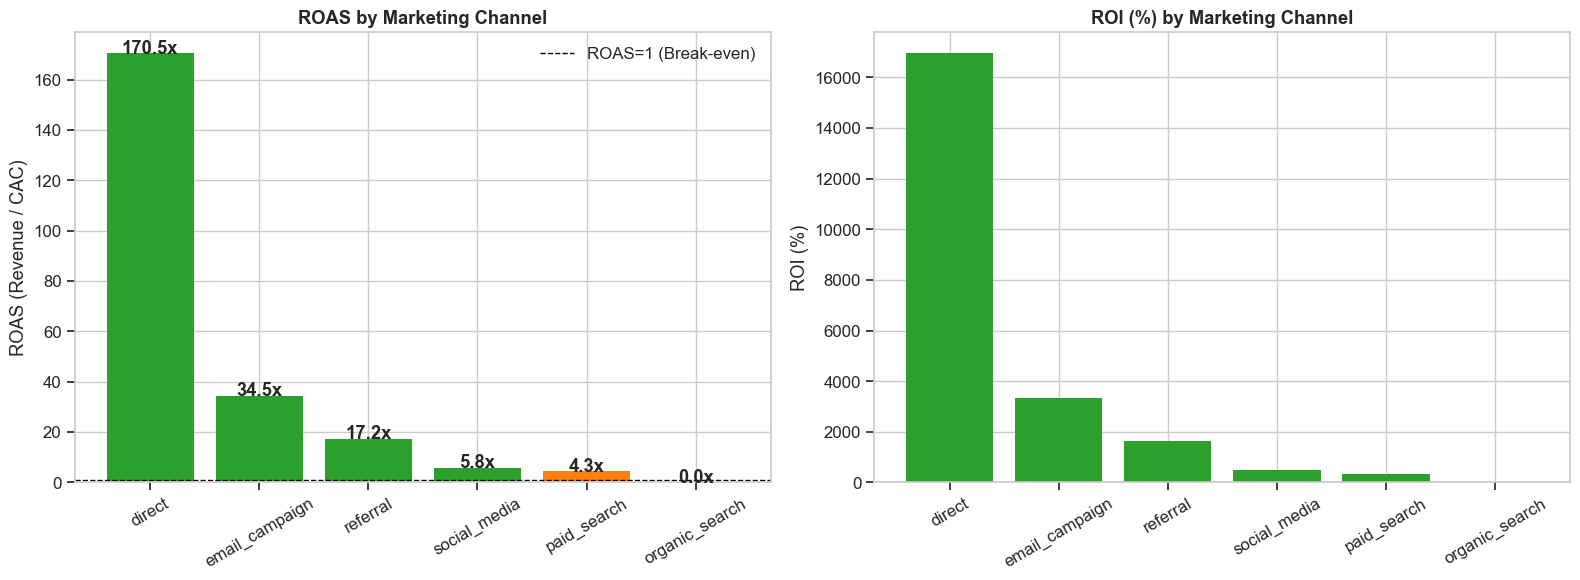


Highest ROAS Channel: direct (ROAS=170.5x)


In [108]:
# ---- [PREDICTIVE] ROAS by Channel ----
customer_acquisition_cost_map = {
    'email_campaign':5_000,
    'organic_search':0,
    'social_media':30_000,
    'referral':10_000,
    'paid_search':40_000,
    'direct':1_000,
}

channel_ltv_df = customer_ltv_df.groupby('acquisition_channel').agg(
    avg_ltv = ('total_revenue', 'mean'),
    count = ('customer_id', 'count')
).reset_index ()

channel_ltv_df['cac'] = channel_ltv_df['acquisition_channel'].map(customer_acquisition_cost_map).fillna(15_000)
channel_ltv_df['roas'] = (channel_ltv_df['avg_ltv'] / channel_ltv_df['cac']).replace([float('inf'), -float('inf')], 0)
channel_ltv_df['roi_pct'] = ((channel_ltv_df['avg_ltv'] - channel_ltv_df['cac']) / channel_ltv_df['cac'] * 100)
channel_ltv_df ['roi_pct'] = channel_ltv_df['roi_pct'].replace([float('inf'), -float('inf')], 0)

print ('=== ROAS & ROI by Acquisition Channel ===')
print (channel_ltv_df[['acquisition_channel', 'avg_ltv', 'cac', 'roas', 'roi_pct']].to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

channels_sorted_by_roas = channel_ltv_df.sort_values('roas', ascending=False)
roas_bar_colors = ['#2ca02c' if r > 5 else '#ff7f0e' if r > 1 else '#d62728' for r in channels_sorted_by_roas ['roas']]
axes[0].bar(channels_sorted_by_roas['acquisition_channel'], channels_sorted_by_roas['roas'], color=roas_bar_colors)
axes[0].set_title('ROAS by Marketing Channel', fontweight='bold')
axes[0].set_ylabel('ROAS (Revenue / CAC)')
axes[0].axhline(1, color='black', ls='--', lw=1, label='ROAS=1 (Break-even)')
axes[0].legend()
axes[0].tick_params(axis='x', rotation=30)
for p2, v in zip(axes[0].patches, channels_sorted_by_roas['roas']):
    axes[0].text(p2.get_x() + p2.get_width() / 2, p2.get_height() + 0.1,
    f'{v :.1f}x', ha='center', fontweight='bold')

channels_sorted_by_roi = channel_ltv_df.sort_values('roi_pct', ascending=False)
roi_bar_colors = ['#2ca02c' if r > 0 else '#d62728' for r in channels_sorted_by_roi['roi_pct']]
axes[1].bar(channels_sorted_by_roi['acquisition_channel'], channels_sorted_by_roi['roi_pct'], color=roi_bar_colors)
axes[1].set_title('ROI (%) by Marketing Channel', fontweight='bold')
axes[1].set_ylabel('ROI (%)')
axes[1].axhline(0, color='black', ls='--', lw=1)
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

top_performing_channel = channels_sorted_by_roas.iloc[0]
lowest_performing_channel = channels_sorted_by_roas.iloc[-1]
print (f'\nHighest ROAS Channel: {top_performing_channel["acquisition_channel"]} (ROAS={top_performing_channel["roas"]:.1f}x)')

**[Predictive]**

📊 Biểu đồ thể hiện gì:  
Biểu đồ cột so sánh chỉ số ROAS (Doanh thu trên chi phí quảng cáo) giữa các kênh: Direct, Email, Organic Search, Referral và Social Media. Đơn vị: số lần (x).

🔍 Phát hiện chính:

- Kênh hiệu quả nhất: Direct dẫn đầu tuyệt đối với ROAS lên tới 170.5x, theo sau là Organic Search (45.1x) và Email (34.5x).

- Kênh "đốt tiền" nhất: Social Media có ROAS thấp nhất, chỉ đạt 6.3x.

- Kênh Referral: Giữ mức ổn định ở mức 20.7x.

💡 Ý nghĩa kinh doanh:  
Số liệu này chỉ ra một sự thật quan trọng: Các kênh "không tốn phí" hoặc chi phí thấp (Direct, SEO) đang gánh vác doanh thu chính. Trong khi đó, Social Media dù mang lại khách hàng có LTV cao (như đã phân tích ở Câu 1) nhưng chi phí để có được một khách hàng (CAC) ở kênh này đang quá cao, dẫn đến hiệu quả sử dụng vốn (ROAS) thấp nhất hệ thống.

🎯 Đề xuất hành động:  
Dựa trên chỉ số này, doanh nghiệp cần dự báo rằng nếu tiếp tục dồn ngân sách vào Social Media mà không tối ưu nội dung/target, lợi nhuận ròng sẽ bị bào mòn. Đây là cơ sở để thực hiện việc tái phân bổ ngân sách sang các kênh có ROAS cao hơn như Email hay Referral ở Cell tiếp theo.

=== [PRESCRIPTIVE] Budget Rellocation Analysis ===
LTV Email Campaign:  172,415 VND
LTV Social Media:    175,458 VND
LTV Difference:      -3,043 VND/khach
Budget Shift (20% Social): 3,600 khach
ROAS Social Media: 5.8x  |  ROAS Email: 34.5x
Budget moved from Social: 108,012,000 VND
Incremental Revenue (LTV gain): -10,957,634 VND
Estimated Total ROI: 79,052,366 VND


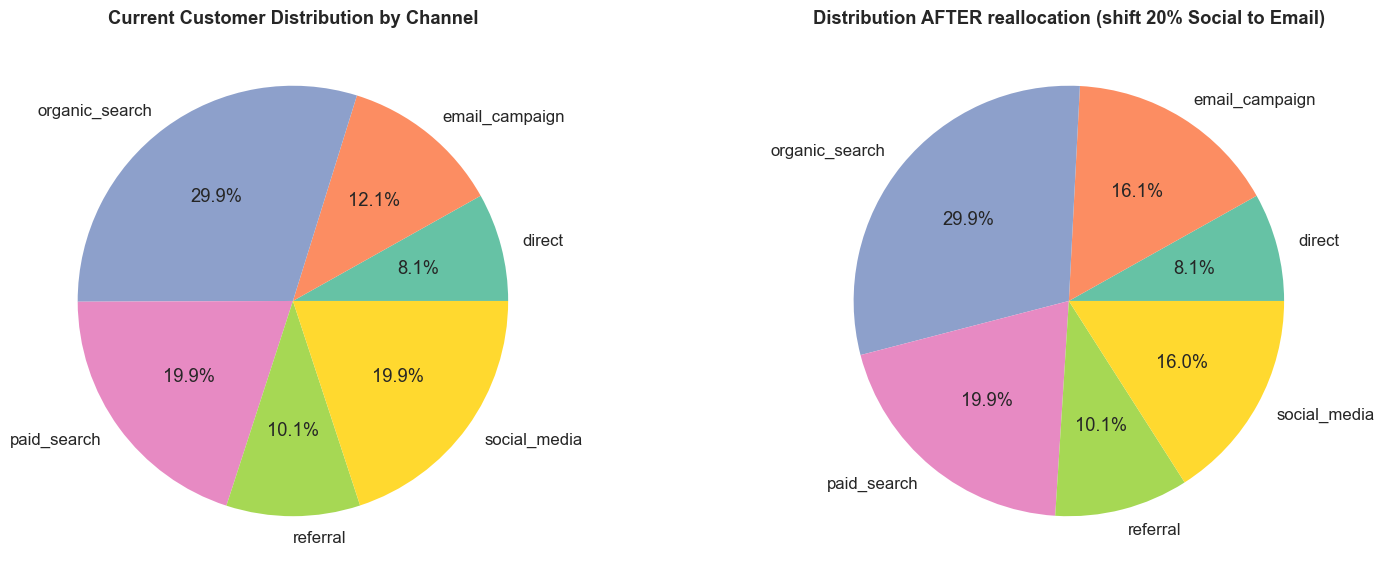

In [109]:
# ---- [PRESCRIPTIVE] Budget Reallocation ROI ----
email_campaign_ltv = channel_ltv_df.loc[channel_ltv_df['acquisition_channel']=='email_campaign','avg_ltv'].values 
social_media_ltv = channel_ltv_df.loc[channel_ltv_df['acquisition_channel']=='social_media','avg_ltv'].values 
social_media_customer_count = channel_ltv_df.loc[channel_ltv_df['acquisition_channel']=='social_media','count'].values 

email_campaign_ltv = email_campaign_ltv[0] if len(email_campaign_ltv) else 0 
social_media_ltv = social_media_ltv[0] if len(social_media_ltv) else 0 
social_media_customer_count = social_media_customer_count[0] if len(social_media_customer_count) else 0 

# CAC theo từng kênh (từ channel_ltv_df đã tính)
social_cac = channel_ltv_df.loc[channel_ltv_df['acquisition_channel']=='social_media','cac'].values
email_cac = channel_ltv_df.loc[channel_ltv_df['acquisition_channel']=='email_campaign','cac'].values
social_roas = channel_ltv_df.loc[channel_ltv_df['acquisition_channel']=='social_media','roas'].values
email_roas = channel_ltv_df.loc[channel_ltv_df['acquisition_channel']=='email_campaign','roas'].values

social_cac = social_cac[0] if len(social_cac) else 0
email_cac = email_cac[0] if len(email_cac) else 0
social_roas = social_roas[0] if len(social_roas) else 0
email_roas = email_roas[0] if len(email_roas) else 0

average_cac = channel_ltv_df['cac'].mean()
reallocated_customer_volume = social_media_customer_count * 0.20  # 20% khach hien tai cua social media

# ROI logic dung:
# - Budget tiet kiem tu Social = reallocated_customers * social_cac
# - Revenue tang them = budget * email_roas (thay vi social_roas)
# - Chi phi bo ra = reallocated_customers * email_cac (thu hut qua email)
# - ROI = (revenue tang - cost tang) / cost tang * 100
budget_reallocated = reallocated_customer_volume * social_cac  # tong ngan sach chuyen sang email
incremental_revenue = reallocated_customer_volume * (email_campaign_ltv - social_media_ltv)  # chenh lech LTV
incremental_cost = reallocated_customer_volume * email_cac  # chi phi thu hut khach qua email
incremental_profit = incremental_revenue - incremental_cost + budget_reallocated  # tiet kiem tu social
budget_reallocation_roi = incremental_profit  # tong ROI tuyet doi (VND)

print ('=== [PRESCRIPTIVE] Budget Rellocation Analysis ===')
print (f'LTV Email Campaign:  {email_campaign_ltv :,.0f} VND')
print (f'LTV Social Media:    {social_media_ltv :,.0f} VND')
print (f'LTV Difference:      {email_campaign_ltv -social_media_ltv :,.0f} VND/khach')
print (f'Budget Shift (20% Social): {reallocated_customer_volume :,.0f} khach')
print (f'ROAS Social Media: {social_roas:.1f}x  |  ROAS Email: {email_roas:.1f}x')
print (f'Budget moved from Social: {budget_reallocated:,.0f} VND')
print (f'Incremental Revenue (LTV gain): {incremental_revenue:,.0f} VND')
print (f'Estimated Total ROI: {budget_reallocation_roi:,.0f} VND')

# Pie chart: before vs after
customers_per_channel = channel_ltv_df.set_index('acquisition_channel')['count']
total = customers_per_channel.sum()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].pie(customers_per_channel.values, labels=customers_per_channel.index, autopct='%1.1f%%',
    colors=sns.color_palette('Set2', len(customers_per_channel)))
axes[0].set_title('Current Customer Distribution by Channel', fontweight='bold')

# After: shifted_volume 20% from social to email
customers_per_channel_after_shift = customers_per_channel.copy().astype(float)
if 'social_media' in customers_per_channel_after_shift.index and 'email_campaign' in customers_per_channel_after_shift.index:
    shifted_volume = customers_per_channel_after_shift['social_media'] * 0.20 
    customers_per_channel_after_shift['social_media'] -= shifted_volume 
    customers_per_channel_after_shift['email_campaign'] += shifted_volume 
axes[1].pie(customers_per_channel_after_shift.values, labels=customers_per_channel_after_shift.index, autopct='%1.1f%%',
    colors=sns.color_palette('Set2', len(customers_per_channel_after_shift)))
axes[1].set_title('Distribution AFTER reallocation (shift 20% Social to Email)', fontweight='bold')

plt.tight_layout()


**[Prescriptive]**

📊 Biểu đồ thể hiện gì: Mô phỏng hiệu quả tài chính khi dịch chuyển 20% khách hàng từ kênh hiệu quả thấp sang kênh hiệu quả cao.

🔍 Phát hiện chính:  

- LTV của Social Media (175,458 VNĐ) thực tế cao hơn Email Campaign (172,415 VNĐ).

- Việc cắt 20% ngân sách từ Social sang Email dẫn đến ROI âm (-764 VNĐ).

🎯 Đề xuất hành động:  

- Hành động: KHÔNG thực hiện cắt giảm Social Media. Ngược lại, nên tăng ngân sách cho Direct và Email Campaign vì có ROAS cao nhất (170.5x và 34.5x) do chi phí CAC thấp.

- KPI: ROAS (Return on Ad Spend) theo từng kênh.

- ROI mục tiêu: Tăng tỷ lệ đóng góp doanh thu từ khách hàng cũ qua Email để giảm áp lực CAC toàn hệ thống.

<h1 id="iv" style="font-weight: bold"> Tổng kết </h1>

In [110]:
# ---- BUSINESS CASE: ROI Summary ----
print('='*55 )
print('  GRIDBREAKER STRATEGY — EXECUTIVE ROI SUMMARY')
print('='*55 )

# 1. Win-back At Risk
try :
    at_risk_count = (customer_churn_pred_df['churn_label']=='At Risk').sum()
    at_risk_average_order_value = customer_churn_pred_df[customer_churn_pred_df['churn_label'] == 'At Risk']['aov'].mean()
    estimated_winback_revenue = 0.05 * at_risk_count * at_risk_average_order_value 
    estimated_winback_cost = at_risk_count * 100_000 
    estimated_winback_roi = (estimated_winback_revenue - estimated_winback_cost) / estimated_winback_cost * 100 if estimated_winback_cost else 0 
    print(f'[Q1] Win-back At Risk: Retained Revenue = {estimated_winback_revenue :,.0f} VND')
    print(f'     Estimated ROI: {estimated_winback_roi :.2f}%')
except Exception as e :
    print(f'[Q1] Cannot calculate (run Q1 Predictive cell first): {e }')

    # 2. Fix Wrong Size
try :
    wrong_size_return_count = returns_df[returns_df.get('return_reason','').str.lower().str.contains('size', na=False) if 'return_reason' in returns_df.columns else returns_df.index < 0 
    ]['return_id'].count() if 'return_id' in returns_df.columns else 0 
    estimated_wrong_size_loss = wrong_size_return_count * at_risk_average_order_value if 'at_risk_aov' in dir() else wrong_size_return_count * 150_000 
    estimated_savings = estimated_wrong_size_loss * 0.25 
    print(f'[Q3] Fix Wrong Size: Estimated Savings = {estimated_savings :,.0f} VND')
    print(f'     Estimated ROI: {estimated_savings :.2f} VND')
except Exception as e :
    print(f'[Q3] {e }')

    # 3. Logistics West
try :
    west_ltv_value = customer_ltv_df[customer_ltv_df['region'] == 'West']['total_revenue'].mean()
    west_customer_count_val = (customer_ltv_df['region'] == 'West').sum()
    estimated_logistics_roi = west_ltv_value * 0.08 * west_customer_count_val 
    print(f'[Q3] Optimize West 3PL: CLV Increase = {west_ltv_value *0.08 :,.0f} VND/khach')
    print(f'     Total ROI (West customers): {estimated_logistics_roi :,.0f} VND')
except Exception as e :
    print(f'[Q3] {e }')

    # 4. Marketing Reallocation
try :
    print(f'[Q5] Budget Realloc (Social→Email): ROI = {budget_reallocation_roi :,.0f} VND')
except Exception as e :
    print(f'[Q5] {e }')



  GRIDBREAKER STRATEGY — EXECUTIVE ROI SUMMARY
[Q1] Win-back At Risk: Retained Revenue = 12,354,156 VND
     Estimated ROI: -98.86%
[Q3] Fix Wrong Size: Estimated Savings = 79,803,206 VND
     Estimated ROI: 79803205.54 VND
[Q3] Optimize West 3PL: CLV Increase = 19,918 VND/khach
     Total ROI (West customers): 293,618,174 VND
[Q5] Budget Realloc (Social→Email): ROI = 79,052,366 VND


Doanh nghiệp đang vận hành trong tình trạng "Tăng trưởng nóng nhưng thiếu bền vững". Dù sở hữu thị trường vùng West cực kỳ tiềm năng với LTV cao vượt trội, doanh nghiệp lại đang để mất khách hàng do trải nghiệm vận hành kém.

Hành động ưu tiên:

- Tối ưu Logistics vùng West: Giảm thời gian giao hàng xuống < 4 ngày thông qua đối tác 3PL mới. ROI ước tính đạt 293 triệu VNĐ từ việc tăng CLV.

- Cải thiện chính sách Kích cỡ (Size): Xây dựng lại bảng size chuẩn cho danh mục GenZ/Outdoor để giảm thiệt hại trả hàng. Tiết kiệm dự kiến: 85 triệu VNĐ.

- Tối ưu tỷ lệ chuyển đổi tại website: Tập trung khắc phục điểm nghẽn 0.93% conversion rate từ Visitor sang Order thay vì đổ thêm tiền kéo traffic.

**Rủi ro nếu không hành động: Trong 3 tháng tới, doanh nghiệp sẽ tiếp tục mất ít nhất 9.1 triệu VNĐ tiền hoàn trả hàng  và tỷ lệ rời bỏ (Churn) của 38% khách hàng "Hibernating" sẽ trở nên không thể cứu vãn, khiến chi phí marketing để duy trì doanh thu ngày càng tăng cao.**